<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=320932590" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing

In [2]:
# A GPU will be used, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers = tickers.sort_values(by=['cik','ticker']).drop_duplicates(subset=['cik'],keep='first').set_index('cik')
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv',
                     index_col=['date','ticker'],
                     date_format='ISO8601',
                    ).replace({0.0:np.nan}).dropna()
prices.index.rename(['snapshot','ticker'],inplace=True)
prices

,,exchange,price
snapshot,ticker,,
2010-02-01,A,NYSE - Delayed Quote,20.05
2010-03-01,A,NYSE - Delayed Quote,22.50
2010-04-01,A,NYSE - Delayed Quote,24.60
2010-05-01,A,NYSE - Delayed Quote,25.94
2010-06-01,A,NYSE - Delayed Quote,23.15
...,...,...,...
2026-01-01,ZYME,NasdaqGS - Delayed Quote,26.33
2026-02-01,ZYME,NasdaqGS - Delayed Quote,22.53
2026-03-01,ZYME,NasdaqGS - Delayed Quote,23.29


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages here on Kaggle

In [6]:
keys = ['snapshot','cik','ticker','date']
snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',
                        index_col=keys,
                        usecols=keys+ml_features,
                        date_format='ISO8601',
                        dtype={'cik':str})

# We can only use ciks with a ticker symbol, because the prices dataset is per-ticker.
snapshots = snapshots[snapshots.index.get_level_values('ticker').notna()]

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].index.get_level_values('cik').unique().tolist()
snapshots = snapshots[~snapshots.index.isin(zero_asset_ciks,level='cik')]

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = asset_outliers[asset_outliers<1e-3].index.get_level_values('cik').unique().tolist()
snapshots = snapshots[~snapshots.index.isin(asset_outliers, level='cik')]

# We ensure a window_size number of snapshots of historic data is available for each cik.
ciks_with_history = snapshots.reset_index(level='snapshot').groupby('cik')['snapshot'].count()
ciks_with_history = ciks_with_history[ciks_with_history >= window_size].index.unique().tolist()
snapshots = snapshots[snapshots.index.isin(ciks_with_history, level='cik')]

snapshots = pd.merge(snapshots, prices.drop(columns='exchange'), left_index=True, right_index=True, how='left')
snapshots

Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-05-20 0001948455 ISPR   2026-03-31   0.075911     0.092115   
           0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  
snapshot   cik        ticker date                                     
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68  
           0000001800 ABT    2012-09-30              9.212610  31.43  
           0000002098 ACU    2012-09-30              0.001128  11.04  
           0000002488 AMD    2012-09-29              0.135000   2.40  
           0000002809 AEM    2012-09-30              0.722071  52.46  
...                                                       ...    ...  
2026-05-20 0001948455 ISPR   2026-03-31              0.001501    NaN  
           0001952073 MSGE   2026-03-31              0.341042    NaN  
           0001953366 STHO   2026-03-31             -0.013730    NaN  
           0001955520 KNF    2026-03-31              0.345202    NaN  
           0001964333 BHRB   2026-03-31              0.096788    NaN  

[474514 rows x 4 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in the new column *is_created* whether a row was artificially created or not.

In [7]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates), len(unique_ciks), len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.set_index(['cik','snapshot']).sort_index().drop(columns=['date','ticker'])
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df.info()

There are 160 unique snapshots and 3284 unique ciks for a total of 525440 records.
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 525440 entries, ('0000001750', Timestamp('2013-01-01 00:00:00')) to ('0001964333', Timestamp('2026-04-01 00:00:00'))
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Assets                525440 non-null  float64
 1   Liabilities           525440 non-null  float64
 2   NetCashOperating_ttm  525440 non-null  float64
 3   price                 525440 non-null  float64
 4   is_created            525440 non-null  bool   
dtypes: bool(1), float64(4)
memory usage: 18.7+ MB


The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [8]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [9]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3284, 160, 3])
Labels shape: torch.Size([3284, 160])
Asset multiplier shape: torch.Size([3284])
Cash multiplier shape: torch.Size([160])


device(type='cpu')

Adjusted assets shape: torch.Size([3284, 160])
Adjusted cashflow shape: torch.Size([3284, 160])
Forward shape: torch.Size([3284, 160])
Epoch [1000/6000], Loss=951.13601567
Epoch [2000/6000], Loss=950.38265973
Epoch [3000/6000], Loss=949.92611630
Epoch [4000/6000], Loss=950.06655004
Epoch [5000/6000], Loss=949.78673270
Epoch [6000/6000], Loss=949.86579002


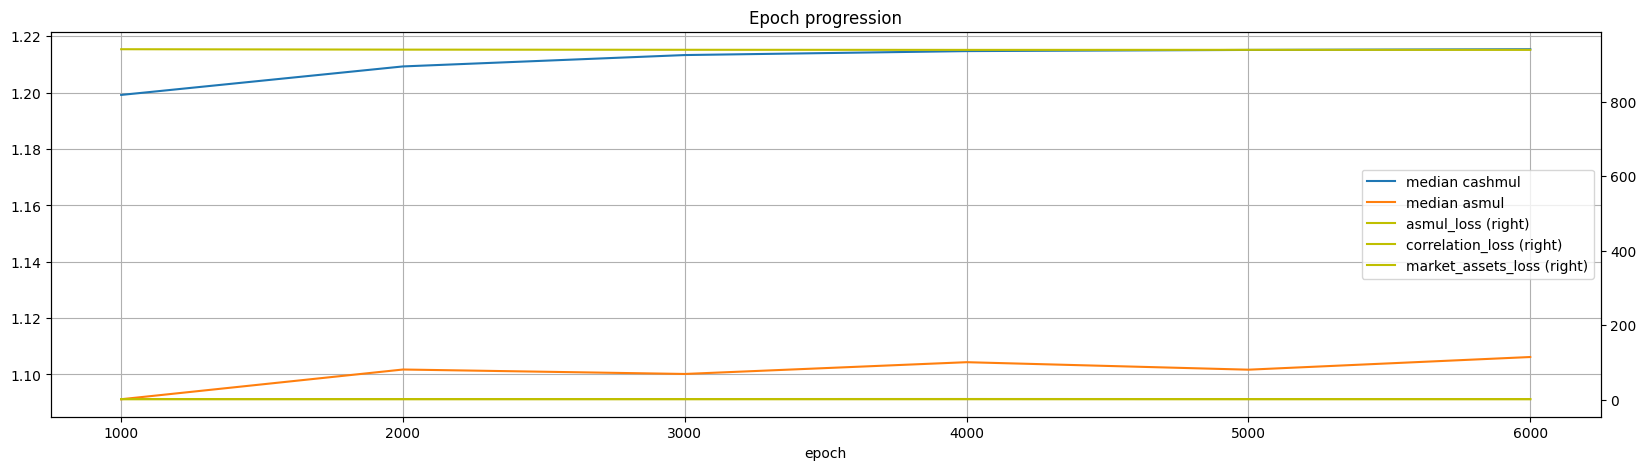

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.199219,1.091186,0.795221,941.888012,1.295791
2000,1.209336,1.101733,0.835768,940.803764,1.221219
3000,1.213373,1.100152,0.831029,940.367443,1.248385
4000,1.214776,1.104331,0.858316,940.120117,1.363278
5000,1.215193,1.101673,0.832373,940.248255,1.214746
6000,1.215443,1.106171,0.852319,940.163007,1.179592


In [10]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [11]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                         
0000001750 2013-01-01  2.189300     1.286500              0.149717  18.68   
           2013-02-01  2.189300     1.286500              0.149717  18.85   
           2013-03-01  2.189300     1.286500              0.149717  17.57   
           2013-04-01  2.217000     1.293000              0.163817  18.39   
           2013-05-01  2.217000     1.293000              0.163817  17.86   
...                         ...          ...                   ...    ...   
0001964333 2025-12-01  7.889037     7.066806              0.153871  65.24   
           2026-01-01  7.889037     7.066806              0.153871  62.31   
           2026-02-01  7.889037     7.066806              0.153871  65.48   
           2026-03-01  7.920626     7.065977              0.107933  64.44   
           2026-04-01  7.920626     7.065977              0.107933  62.29   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2013-01-01  1.020976 -1.375597  0.742773  
           2013-02-01  1.020976 -1.083389  0.786521  
           2013-03-01  1.020976 -0.986162  0.801078  
           2013-04-01  1.020976 -0.796798  0.839975  
           2013-05-01  1.020976 -0.763230  0.845474  
...                         ...       ...       ...  
0001964333 2025-12-01  1.373681  1.489656  3.999431  
           2026-01-01  1.373681  1.505717  4.001902  
           2026-02-01  1.373681  1.671639  4.027432  
           2026-03-01  1.373681  1.735323  4.001737  
           2026-04-01  1.373681  1.548398  3.981561  

[400542 rows x 7 columns]

In [12]:
%%time
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')

# The asset and cash multipliers are not available for the most recent snapshots,
# which are not part of the stock prices dataset.
# We use their latest available values in the model price formula for these recent snapshots. 
result = pd.concat([result.drop(columns=mul_columns),
                    result[mul_columns].groupby('cik',group_keys=False).apply(lambda x:x.interpolate())],
                   axis='columns')

result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(df):
    regressor = linear_model.LinearRegression().fit(X=df['model'].to_frame(), y=df[ml_label])
    return pd.Series({'hype':regressor.coef_[0], 'bias':regressor.intercept_})

result = result.merge(result[['model',ml_label]].dropna().groupby(by=['ticker','cik']).apply(line_fit),
                     left_index=True, right_index=True, how='inner')

result['model_price'] = result['model'] * result['hype'] + result['bias']

# We use the scaled ratio of model price to actual price as overvaluation metric.
result['overvaluation'] = result['model_price'] / result['price']
def interpolate_and_scale(df):
    df['overvaluation'] = -1 * preprocessing.RobustScaler().fit_transform(df['overvaluation'].interpolate().to_frame())
    return df
result = result.groupby('cik',group_keys=False).apply(interpolate_and_scale)

result

CPU times: user 27.6 s, sys: 140 ms, total: 27.8 s
Wall time: 27.8 s


Assets  Liabilities  \
snapshot   cik        ticker date                                 
2013-01-01 0000001750 AIR    2012-11-30   2.189300     1.286500   
           0000001800 ABT    2012-09-30  63.257738    36.243563   
           0000002098 ACU    2012-09-30   0.067661     0.037283   
           0000002488 AMD    2012-09-29   4.612000     3.623000   
           0000002809 AEM    2012-09-30   5.218625     1.828573   
...                                            ...          ...   
2026-05-20 0001948455 ISPR   2026-03-31   0.075911     0.092115   
           0001952073 MSGE   2026-03-31   1.957273     1.909268   
           0001953366 STHO   2026-03-31   0.480355     0.241466   
           0001955520 KNF    2026-03-31   3.817863     2.258538   
           0001964333 BHRB   2026-03-31   7.927711     7.063207   

                                         NetCashOperating_ttm  price  \
snapshot   cik        ticker date                                      
2013-01-01 0000001750 AIR    2012-11-30              0.149717  18.68   
           0000001800 ABT    2012-09-30              9.212610  31.43   
           0000002098 ACU    2012-09-30              0.001128  11.04   
           0000002488 AMD    2012-09-29              0.135000   2.40   
           0000002809 AEM    2012-09-30              0.722071  52.46   
...                                                       ...    ...   
2026-05-20 0001948455 ISPR   2026-03-31              0.001501    NaN   
           0001952073 MSGE   2026-03-31              0.341042    NaN   
           0001953366 STHO   2026-03-31             -0.013730    NaN   
           0001955520 KNF    2026-03-31              0.345202    NaN   
           0001964333 BHRB   2026-03-31              0.096788    NaN   

                                            asmul   cashmul     model  \
snapshot   cik        ticker date                                       
2013-01-01 0000001750 AIR    2012-11-30  1.020976 -1.375597  0.742773   
           0000001800 ABT    2012-09-30  0.887437 -1.375597  7.220866   
           0000002098 ACU    2012-09-30  0.980176 -1.375597  0.027485   
           0000002488 AMD    2012-09-29  0.207432 -1.375597 -2.852029   
           0000002809 AEM    2012-09-30  0.411231 -1.375597 -0.675790   
...                                           ...       ...       ...   
2026-05-20 0001948455 ISPR   2026-03-31  4.799181  1.548398  0.274520   
           0001952073 MSGE   2026-03-31  1.309234  1.548398  1.181329   
           0001953366 STHO   2026-03-31  1.043229  1.548398  0.238395   
           0001955520 KNF    2026-03-31  0.742819  1.548398  1.111953   
           0001964333 BHRB   2026-03-31  1.373681  1.548398  3.976807   

                                               hype       bias  model_price  \
snapshot   cik        ticker date                                             
2013-01-01 0000001750 AIR    2012-11-30  101.359298 -67.057982     8.228932   
           0000001800 ABT    2012-09-30    2.495834   1.661756    19.683842   
           0000002098 ACU    2012-09-30  269.397695   7.449351    14.853744   
           0000002488 AMD    2012-09-29   13.205730  51.291341    13.628221   
           0000002809 AEM    2012-09-30   28.319645  29.661110    10.522968   
...                                             ...        ...          ...   
2026-05-20 0001948455 ISPR   2026-03-31    1.374258   3.962382     4.339643   
           0001952073 MSGE   2026-03-31   54.111404   6.656621    70.580017   
           0001953366 STHO   2026-03-31   22.427353   2.539765     7.886325   
           0001955520 KNF    2026-03-31   61.980711  17.230210    86.149872   
           0001964333 BHRB   2026-03-31    3.010728  50.369784    62.342867   

                                         overvaluation  
snapshot   cik        ticker date                       
2013-01-01 0000001750 AIR    2012-11-30       2.027362  
           0000001800 ABT    2012-09-30       1.619904  
           0000002098 ACU    

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

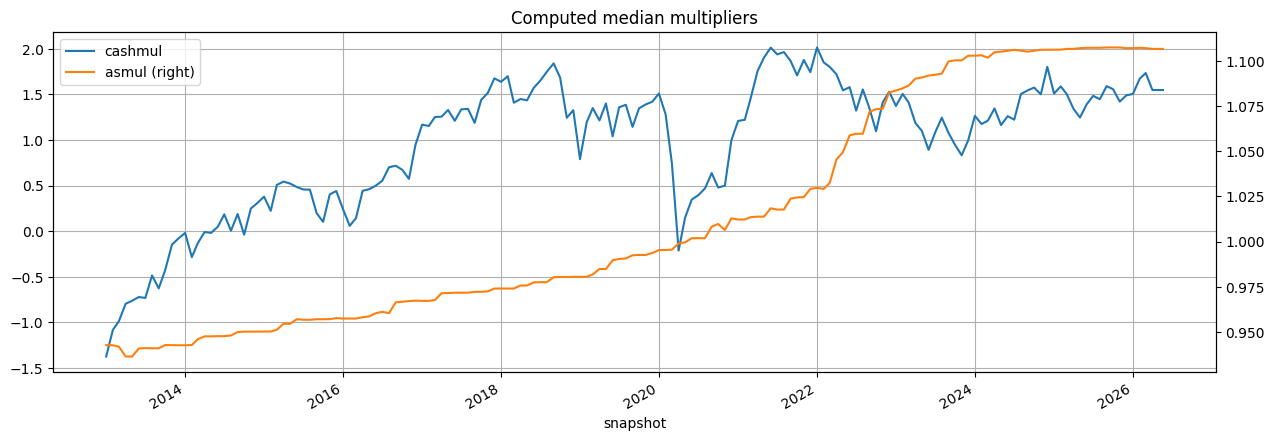

Median asset_multiplier per cik: 1.1065847873687744
Median asset_multiplier per snapshot: 0.9924957156181335


In [13]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

Let's examine the distribution of the achieved correlations:

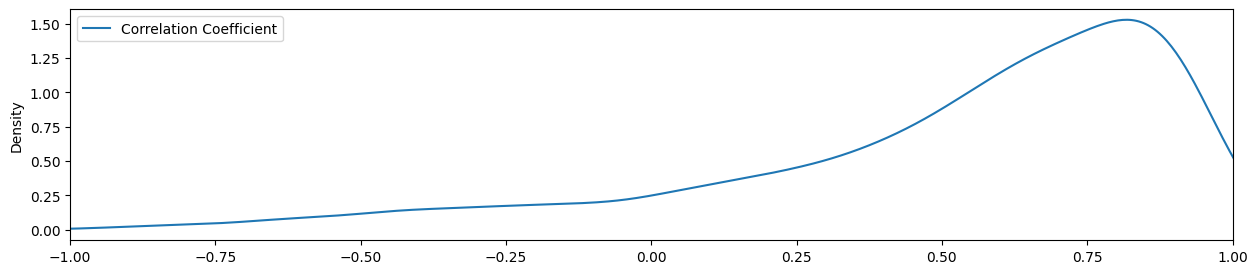

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().unstack().sum(axis='columns')/2 - 1
model_corr = model_corr.rename('Correlation Coefficient').to_frame()
model_corr.plot.density(bw_method=0.2,figsize=(15,3),xlim=(-1,1))
plt.show()

In [15]:
# Reality check for our fair price calculations:
# compute their correlation with the actual prices
result[['price','model_price']].dropna().corr()

,price,model_price
price,1.000000,0.900899
model_price,0.900899,1.000000


In [16]:
# We can now output the results for later use in other models/notebooks/datasets
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

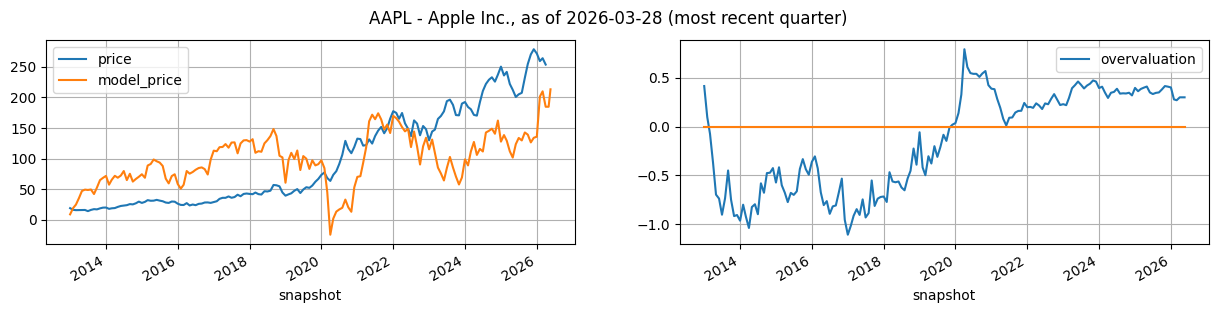

AAPL(0000320193) model_price = 0.995797 * (0.640720 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +23.828803


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,359.241,285.508,111.482,271.86,0.64072,1.505717,112.525378,0.995797,23.828803,135.881240,0.400535
2026-02-01,2025-12-27,379.297,291.107,135.472,259.48,0.64072,1.671639,178.376581,0.995797,23.828803,201.455672,0.278102
2026-03-01,2025-12-27,379.297,291.107,135.472,264.18,0.64072,1.735323,187.003978,0.995797,23.828803,210.046809,0.269821
2026-04-01,2025-12-27,379.297,291.107,135.472,253.79,0.64072,1.548398,161.680899,0.995797,23.828803,184.830162,0.299397
2026-05-01,2025-12-27,379.297,291.107,135.472,NaN,0.64072,1.548398,161.680899,0.995797,23.828803,184.830162,0.299397
2026-05-20,2026-03-28,371.082,264.591,140.222,NaN,0.64072,1.548398,190.288274,0.995797,23.828803,213.317301,0.299397


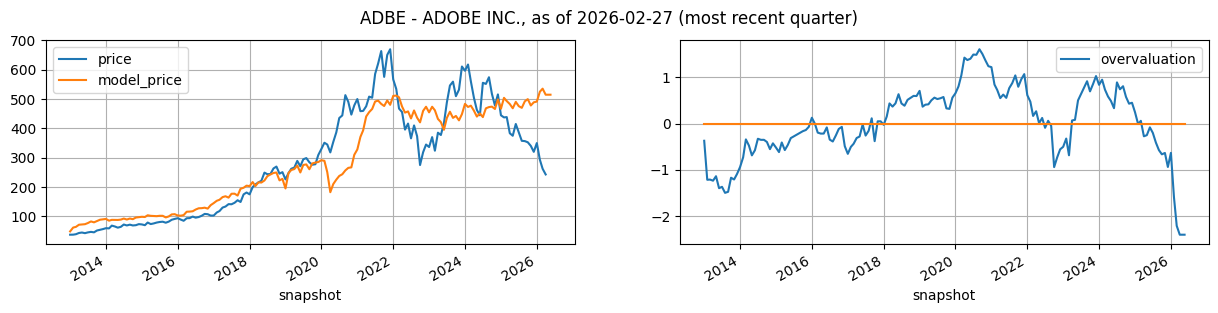

ADBE(0000796343) model_price = 16.175342 * (1.271424 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -63.610537


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-08-29,28.754,16.984,9.792,349.99,1.271424,1.505717,34.318501,16.175342,-63.610537,491.502937,-0.635270
2026-02-01,2025-11-28,29.496,17.873,10.031,293.25,1.271424,1.671639,36.397125,16.175342,-63.610537,525.125398,-1.593145
2026-03-01,2025-11-28,29.496,17.873,10.031,262.41,1.271424,1.735323,37.035939,16.175342,-63.610537,535.458434,-2.212513
2026-04-01,2026-02-27,29.704,18.271,10.507,243.08,1.271424,1.548398,35.764390,16.175342,-63.610537,514.890692,-2.405026
2026-05-01,2026-02-27,29.704,18.271,10.507,NaN,1.271424,1.548398,35.764390,16.175342,-63.610537,514.890692,-2.405026
2026-05-20,2026-02-27,29.704,18.271,10.507,NaN,1.271424,1.548398,35.764390,16.175342,-63.610537,514.890692,-2.405026


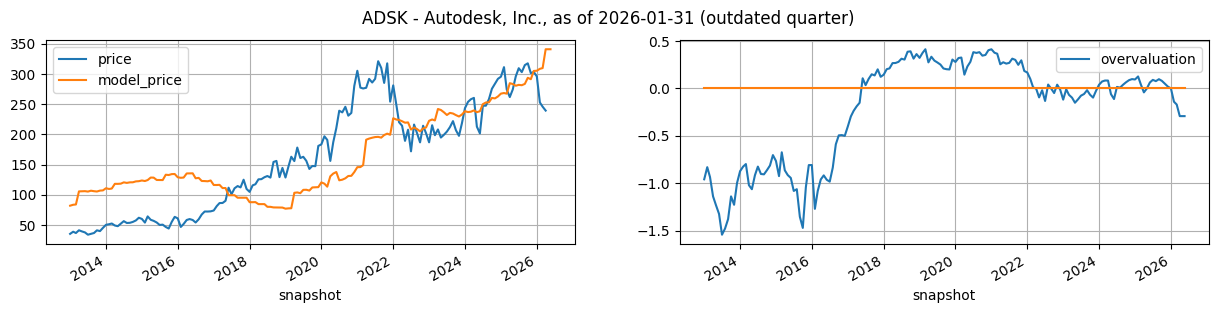

ADSK(0000769397) model_price = 8.949497 * (3.580105 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -8.143280


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-31,11.198,8.305,2.155,296.01,3.580105,1.505717,35.029832,8.949497,-8.14328,305.356096,0.000655
2026-02-01,2025-10-31,11.198,8.305,2.155,252.87,3.580105,1.671639,35.387393,8.949497,-8.14328,308.556091,-0.139745
2026-03-01,2025-10-31,11.198,8.305,2.155,245.87,3.580105,1.735323,35.524632,8.949497,-8.14328,309.784311,-0.169318
2026-04-01,2026-01-31,12.467,9.422,2.452,239.40,3.580105,1.548398,39.007836,8.949497,-8.14328,340.957235,-0.291574
2026-05-01,2026-01-31,12.467,9.422,2.452,NaN,3.580105,1.548398,39.007836,8.949497,-8.14328,340.957235,-0.291574
2026-05-20,2026-01-31,12.467,9.422,2.452,NaN,3.580105,1.548398,39.007836,8.949497,-8.14328,340.957235,-0.291574


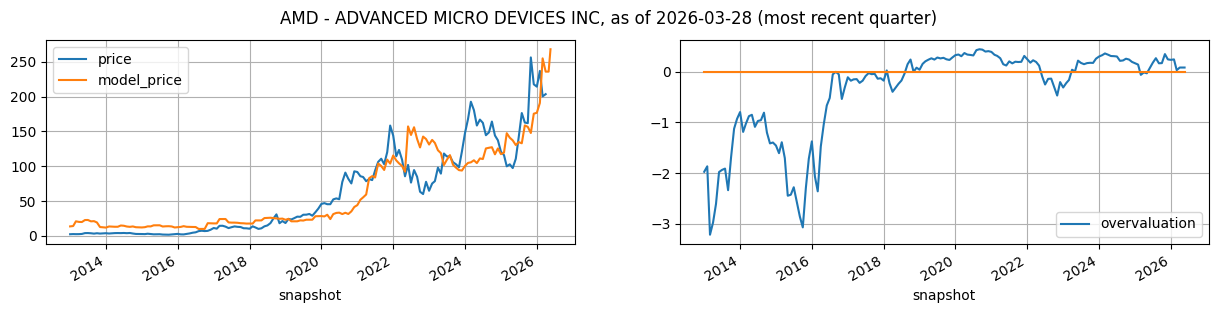

AMD(0000002488) model_price = 13.205730 * (0.207432 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.291341


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,76.891,16.101,6.408,214.16,0.207432,1.505717,9.497301,13.20573,51.291341,176.710132,0.232904
2026-02-01,2025-09-27,76.891,16.101,6.408,236.73,0.207432,1.671639,10.560528,13.20573,51.291341,190.750820,0.241709
2026-03-01,2025-12-27,76.926,13.927,7.709,200.21,0.207432,1.735323,15.407530,13.20573,51.291341,254.759027,0.029446
2026-04-01,2025-12-27,76.926,13.927,7.709,203.43,0.207432,1.548398,13.966527,13.20573,51.291341,235.729524,0.081153
2026-05-01,2025-12-27,76.926,13.927,7.709,NaN,0.207432,1.548398,13.966527,13.20573,51.291341,235.729524,0.081153
2026-05-20,2026-03-28,79.642,15.180,9.725,NaN,0.207432,1.548398,16.398483,13.20573,51.291341,267.845287,0.081153


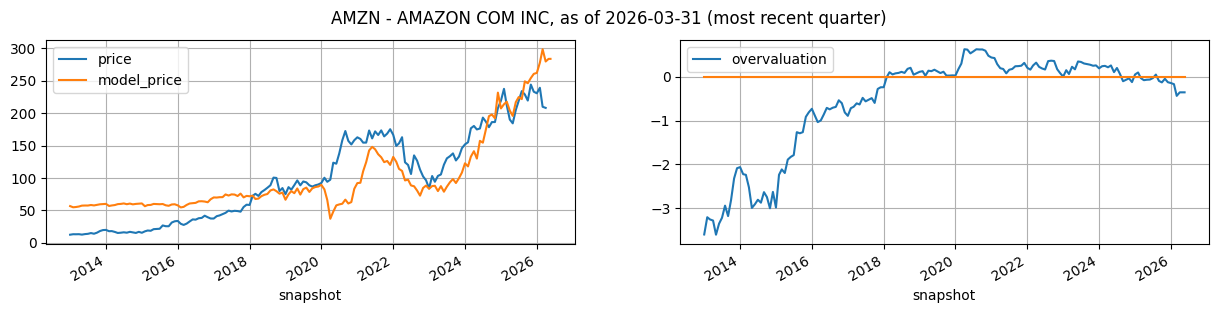

AMZN(0001018724) model_price = 0.699473 * (0.603453 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +62.683177


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,727.921,358.290,135.738750,230.82,0.603453,1.505717,285.360148,0.699473,62.683177,262.284884,-0.141098
2026-02-01,2025-09-30,727.921,358.290,135.738750,239.30,0.603453,1.671639,307.882167,0.699473,62.683177,278.038427,-0.167222
2026-03-01,2025-12-31,818.042,406.977,144.561750,210.00,0.603453,1.735323,337.534077,0.699473,62.683177,298.779136,-0.433805
2026-04-01,2025-12-31,818.042,406.977,144.561750,208.27,0.603453,1.548398,310.511898,0.699473,62.683177,279.877853,-0.353143
2026-05-01,2026-03-31,916.630,474.716,153.635917,NaN,0.603453,1.548398,316.316528,0.699473,62.683177,283.938034,-0.353143
2026-05-20,2026-03-31,916.630,474.716,153.635917,NaN,0.603453,1.548398,316.316528,0.699473,62.683177,283.938034,-0.353143


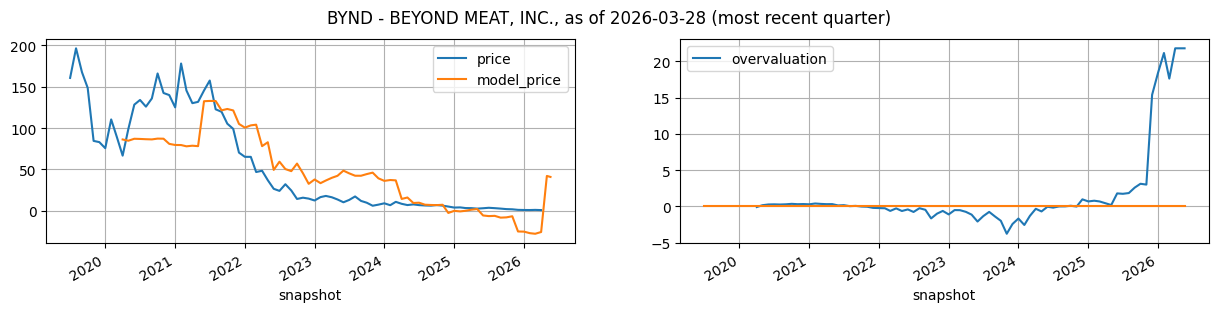

BYND(0001655210) model_price = 88.540115 * (1.743050 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +21.542929


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,0.599669,1.383734,-0.127090,0.820,1.74305,1.505717,-0.529843,88.540115,21.542929,-25.369400,18.428833
2026-02-01,2025-09-27,0.599669,1.383734,-0.127090,0.763,1.74305,1.671639,-0.550930,88.540115,21.542929,-27.236445,21.162992
2026-03-01,2025-09-27,0.599669,1.383734,-0.127090,0.946,1.74305,1.735323,-0.559023,88.540115,21.542929,-27.953053,17.630340
2026-04-01,2025-09-27,0.599669,1.383734,-0.127090,0.702,1.74305,1.548398,-0.535267,88.540115,21.542929,-25.849670,21.810224
2026-05-01,2025-12-31,0.614747,0.615744,-0.144931,NaN,1.74305,1.548398,0.231380,88.540115,21.542929,42.029320,21.810224
2026-05-20,2026-03-28,0.579464,0.600547,-0.123813,NaN,1.74305,1.548398,0.217776,88.540115,21.542929,40.824824,21.810224


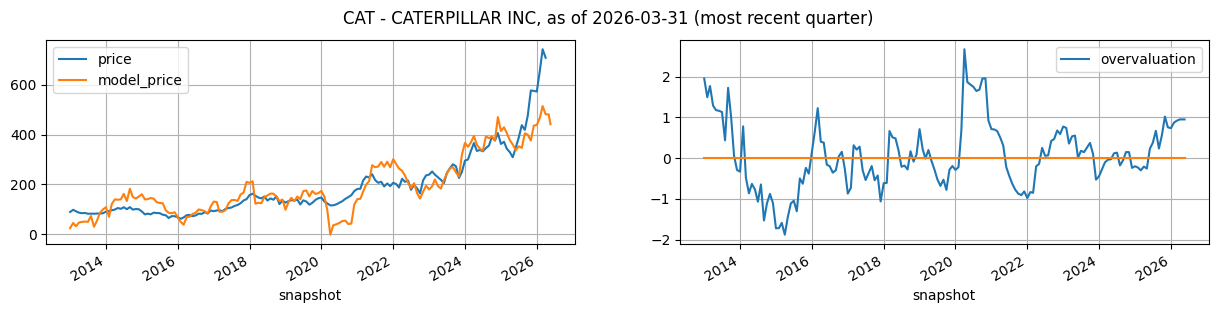

CAT(0000018230) model_price = 15.123770 * (1.278904 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -531.556561


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,93.722,73.063,11.541,572.87,1.278904,1.505717,64.175920,15.12377,-531.556561,439.025310,0.736920
2026-02-01,2025-09-30,93.722,73.063,11.541,657.36,1.278904,1.671639,66.090824,15.12377,-531.556561,467.985872,0.872264
2026-03-01,2025-12-31,98.585,77.267,11.739,742.83,1.278904,1.735323,69.184705,15.12377,-531.556561,514.777015,0.919305
2026-04-01,2025-12-31,98.585,77.267,11.739,708.46,1.278904,1.548398,66.990394,15.12377,-531.556561,481.590768,0.952176
2026-05-01,2025-12-31,98.585,77.267,11.739,NaN,1.278904,1.548398,66.990394,15.12377,-531.556561,481.590768,0.952176
2026-05-20,2026-03-31,95.550,76.890,12.320,NaN,1.278904,1.548398,64.385540,15.12377,-531.556561,442.195553,0.952176


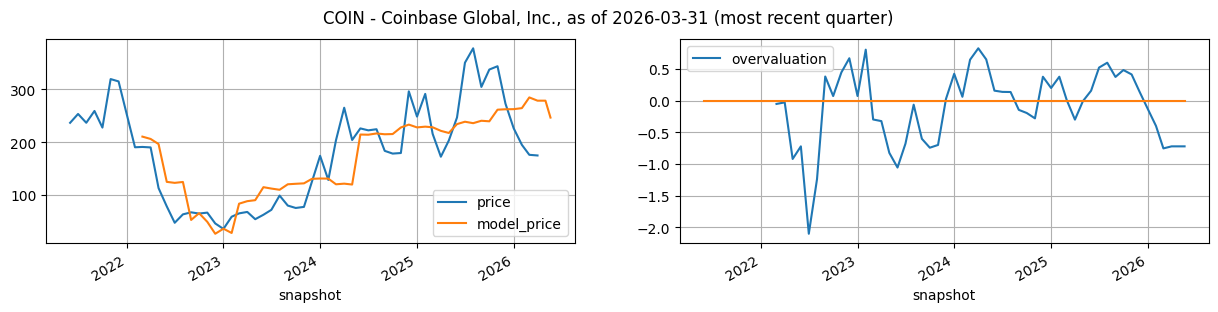

COIN(0001679788) model_price = 13.568014 * (1.015589 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +20.526755


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,31.351367,15.328143,0.872941,226.14,1.015589,1.505717,17.826348,13.568014,20.526755,262.394898,-0.130826
2026-02-01,2025-09-30,31.351367,15.328143,0.872941,194.74,1.015589,1.671639,17.971188,13.568014,20.526755,264.360088,-0.399340
2026-03-01,2025-12-31,29.671832,14.878774,2.426383,175.85,1.015589,1.735323,19.466156,13.568014,20.526755,284.643844,-0.754993
2026-04-01,2025-12-31,29.671832,14.878774,2.426383,174.61,1.015589,1.548398,19.012605,13.568014,20.526755,278.490055,-0.722654
2026-05-01,2025-12-31,29.671832,14.878774,2.426383,NaN,1.015589,1.548398,19.012605,13.568014,20.526755,278.490055,-0.722654
2026-05-20,2026-03-31,28.848792,15.368219,1.756433,NaN,1.015589,1.548398,16.649941,13.568014,20.526755,246.433391,-0.722654


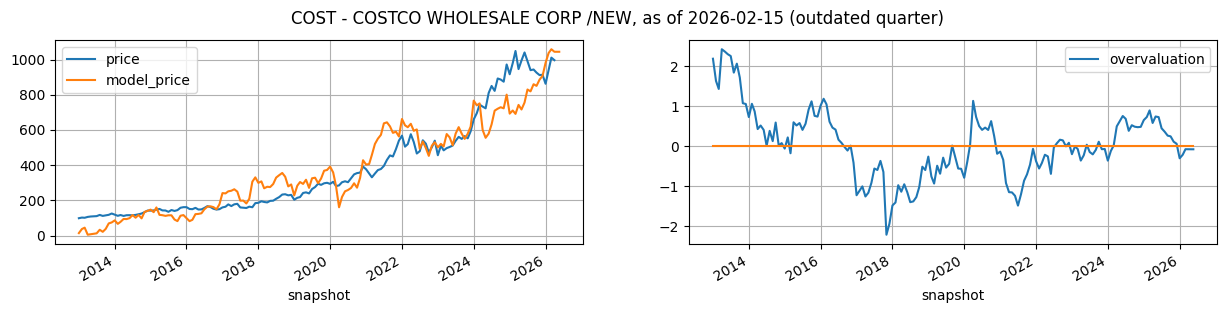

COST(0000909832) model_price = 22.764885 * (0.959073 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -137.473317


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-23,82.790,52.487,14.763,862.34,0.959073,1.505717,49.143519,22.764885,-137.473317,981.273239,-0.305877
2026-02-01,2025-11-23,82.790,52.487,14.763,940.25,0.959073,1.671639,51.593023,22.764885,-137.473317,1037.035908,-0.218331
2026-03-01,2025-11-23,82.790,52.487,14.763,1010.79,0.959073,1.735323,52.533189,22.764885,-137.473317,1058.438695,-0.078698
2026-04-01,2026-02-15,83.639,51.552,15.011,996.43,0.959073,1.548398,51.906874,22.764885,-137.473317,1044.180690,-0.080655
2026-05-01,2026-02-15,83.639,51.552,15.011,NaN,0.959073,1.548398,51.906874,22.764885,-137.473317,1044.180690,-0.080655
2026-05-20,2026-02-15,83.639,51.552,15.011,NaN,0.959073,1.548398,51.906874,22.764885,-137.473317,1044.180690,-0.080655


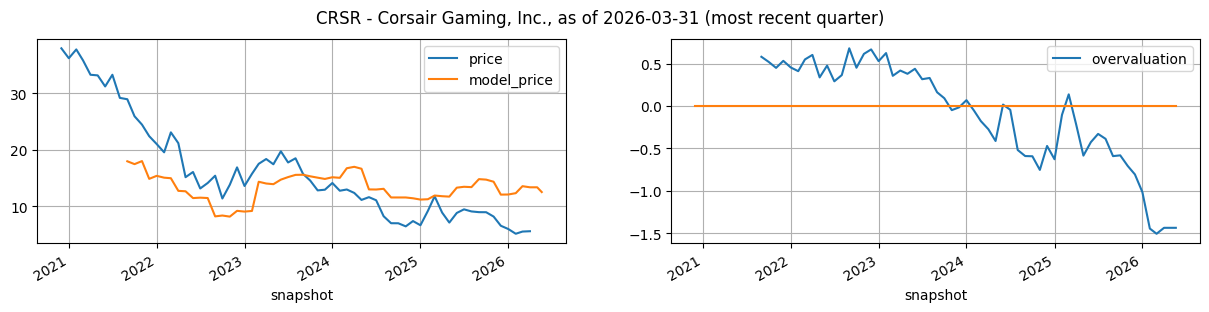

CRSR(0001743759) model_price = 20.952970 * (1.934052 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -26.100546


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,1.198499,0.598269,0.067507,5.94,1.934052,1.505717,1.821337,20.95297,-26.100546,12.061868,-1.015287
2026-02-01,2025-09-30,1.198499,0.598269,0.067507,5.10,1.934052,1.671639,1.832538,20.95297,-26.100546,12.296559,-1.445699
2026-03-01,2025-12-31,1.253784,0.620227,0.050121,5.49,1.934052,1.735323,1.891632,20.95297,-26.100546,13.534772,-1.507081
2026-04-01,2025-12-31,1.253784,0.620227,0.050121,5.55,1.934052,1.548398,1.882264,20.95297,-26.100546,13.338467,-1.436917
2026-05-01,2025-12-31,1.253784,0.620227,0.050121,NaN,1.934052,1.548398,1.882264,20.95297,-26.100546,13.338467,-1.436917
2026-05-20,2026-03-31,1.177340,0.529698,0.061099,NaN,1.934052,1.548398,1.841944,20.95297,-26.100546,12.493657,-1.436917


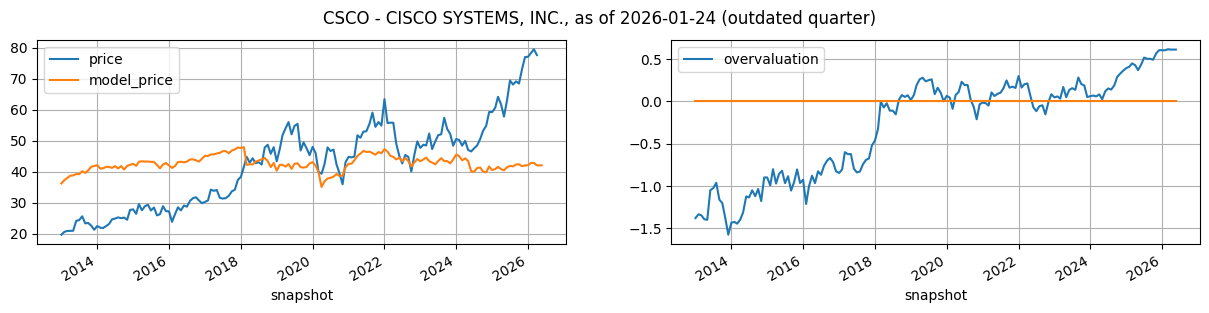

CSCO(0000858877) model_price = 0.321876 * (0.560952 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +37.441965


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-25,121.102,74.229,13.744,77.03,0.560952,1.505717,14.397988,0.321876,37.441965,42.076325,0.605430
2026-02-01,2025-10-25,121.102,74.229,13.744,78.32,0.560952,1.671639,16.678418,0.321876,37.441965,42.810339,0.604855
2026-03-01,2026-01-24,123.371,75.648,13.325,79.46,0.560952,1.735323,16.680390,0.321876,37.441965,42.810974,0.616867
2026-04-01,2026-01-24,123.371,75.648,13.325,77.59,0.560952,1.548398,14.189617,0.321876,37.441965,42.009255,0.612800
2026-05-01,2026-01-24,123.371,75.648,13.325,NaN,0.560952,1.548398,14.189617,0.321876,37.441965,42.009255,0.612800
2026-05-20,2026-01-24,123.371,75.648,13.325,NaN,0.560952,1.548398,14.189617,0.321876,37.441965,42.009255,0.612800


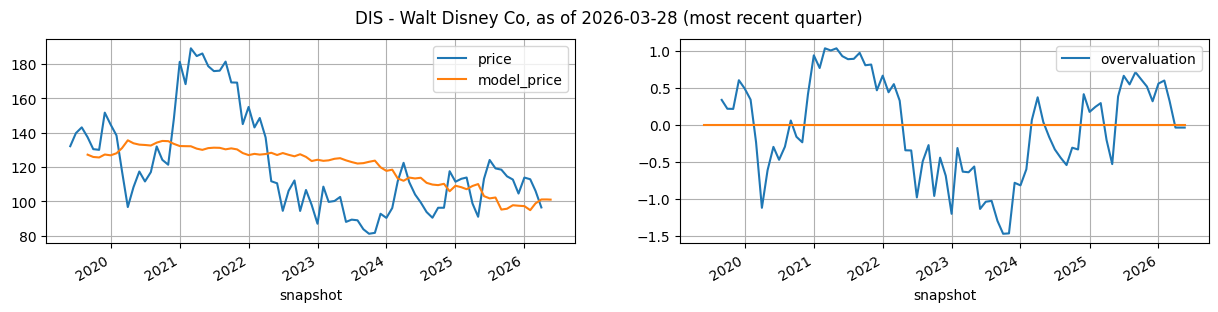

DIS(0001744489) model_price = -0.781092 * (0.886701 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +186.776442


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,197.514,87.645,18.101,113.77,0.886701,1.505717,114.745765,-0.781092,186.776442,97.149409,0.558749
2026-02-01,2025-09-27,197.514,87.645,18.101,112.80,0.886701,1.671639,117.749116,-0.781092,186.776442,94.803515,0.600009
2026-03-01,2025-12-27,202.089,93.613,15.631,106.04,0.886701,1.735323,112.704267,-0.781092,186.776442,98.744008,0.321732
2026-04-01,2025-12-27,202.089,93.613,15.631,96.38,0.886701,1.548398,109.782445,-0.781092,186.776442,101.026220,-0.037118
2026-05-01,2025-12-27,202.089,93.613,15.631,NaN,0.886701,1.548398,109.782445,-0.781092,186.776442,101.026220,-0.037118
2026-05-20,2026-03-28,205.217,96.509,15.792,NaN,0.886701,1.548398,109.909336,-0.781092,186.776442,100.927106,-0.037118


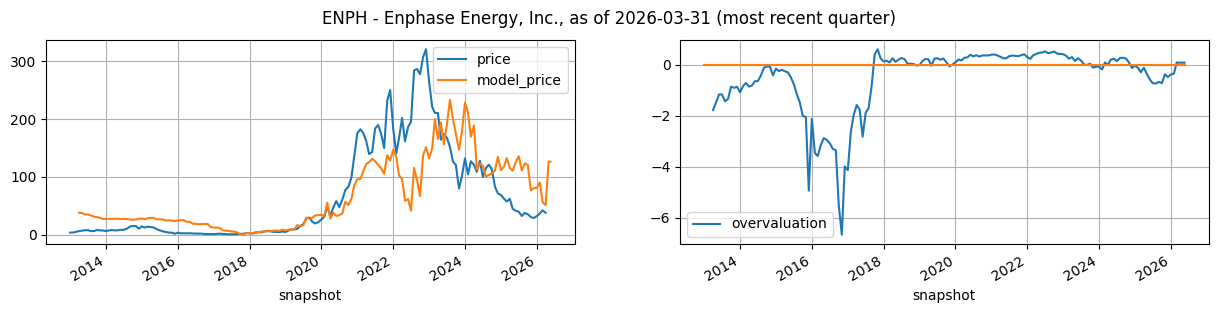

ENPH(0001463101) model_price = 206.543073 * (0.662723 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.346595


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,3.320488,2.325466,0.256253,32.05,0.662723,1.505717,0.260941,206.543073,27.346595,81.242144,-0.388870
2026-02-01,2025-09-30,3.320488,2.325466,0.256253,36.98,0.662723,1.671639,0.303459,206.543073,27.346595,90.023935,-0.349636
2026-03-01,2025-12-31,3.509792,2.422769,0.136540,42.27,0.662723,1.735323,0.140190,206.543073,27.346595,56.301961,0.080911
2026-04-01,2025-12-31,3.509792,2.422769,0.136540,37.81,0.662723,1.548398,0.114668,206.543073,27.346595,51.030421,0.074001
2026-05-01,2026-03-31,2.723923,1.621571,0.190997,NaN,0.662723,1.548398,0.479374,206.543073,27.346595,126.357916,0.074001
2026-05-20,2026-03-31,2.723923,1.621571,0.190997,NaN,0.662723,1.548398,0.479374,206.543073,27.346595,126.357916,0.074001


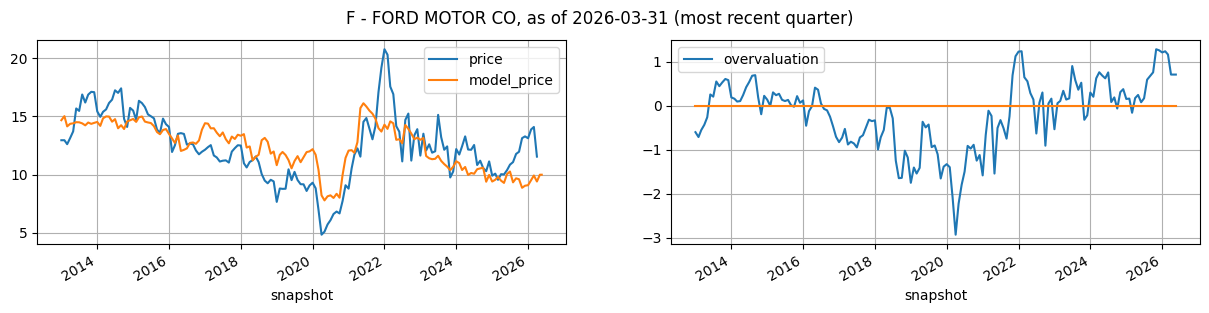

F(0000037996) model_price = 0.129799 * (0.011463 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +37.560888


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,300.990,253.598,20.426,13.12,0.011463,1.505717,-219.391915,0.129799,37.560888,9.084144,1.207836
2026-02-01,2025-09-30,300.990,253.598,20.426,13.88,0.011463,1.671639,-216.002796,0.129799,37.560888,9.524047,1.233421
2026-03-01,2025-12-31,289.160,253.208,21.282,14.09,0.011463,1.735323,-212.962160,0.129799,37.560888,9.918717,1.160253
2026-04-01,2025-12-31,289.160,253.208,21.282,11.54,0.011463,1.548398,-216.940294,0.129799,37.560888,9.402361,0.704352
2026-05-01,2026-03-31,282.434,244.981,18.919,NaN,0.011463,1.548398,-212.449260,0.129799,37.560888,9.985290,0.704352
2026-05-20,2026-03-31,282.434,244.981,18.919,NaN,0.011463,1.548398,-212.449260,0.129799,37.560888,9.985290,0.704352


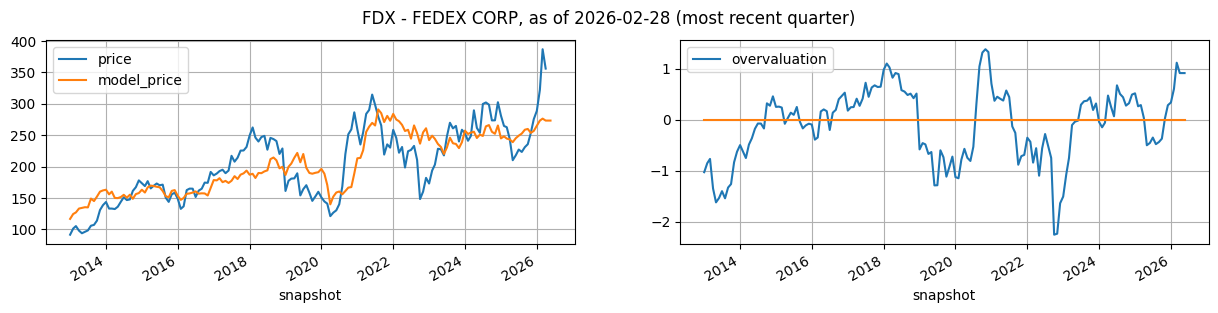

FDX(0001048911) model_price = 6.041718 * (0.888861 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +80.450824


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-30,89.181,61.041,8.198,288.86,0.88886,1.505717,30.572335,6.041718,80.450824,265.160263,0.335253
2026-02-01,2025-11-30,89.181,61.041,8.198,322.25,0.88886,1.671639,31.932562,6.041718,80.450824,273.378371,0.602317
2026-03-01,2025-11-30,89.181,61.041,8.198,387.00,0.88886,1.735323,32.454644,6.041718,80.450824,276.532639,1.115593
2026-04-01,2026-02-28,94.733,64.929,8.179,356.18,0.88886,1.548398,31.939768,6.041718,80.450824,273.421904,0.911890
2026-05-01,2026-02-28,94.733,64.929,8.179,NaN,0.88886,1.548398,31.939768,6.041718,80.450824,273.421904,0.911890
2026-05-20,2026-02-28,94.733,64.929,8.179,NaN,0.88886,1.548398,31.939768,6.041718,80.450824,273.421904,0.911890


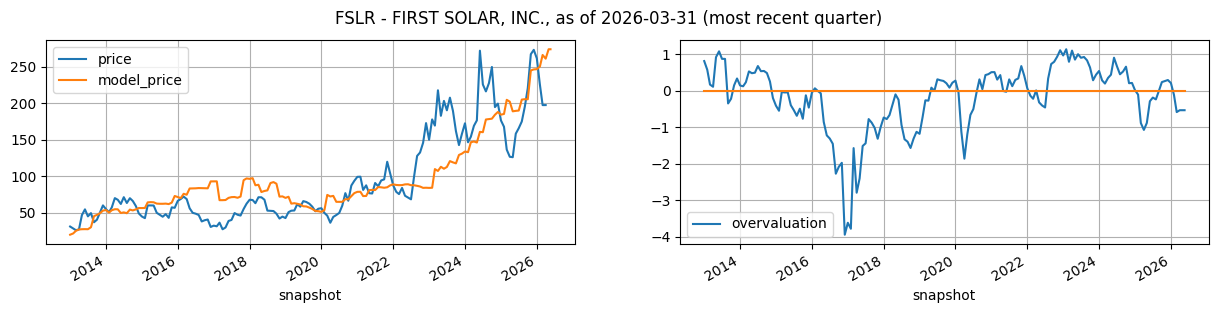

FSLR(0001274494) model_price = 13.095877 * (2.163371 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -108.727009


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,13.459309,4.443997,1.626208,261.23,2.163371,1.505717,27.122089,13.095877,-108.727009,246.460546,0.213083
2026-02-01,2025-09-30,13.459309,4.443997,1.626208,225.52,2.163371,1.671639,27.391913,13.095877,-108.727009,249.994120,-0.111682
2026-03-01,2025-12-31,13.321310,3.783317,2.057105,197.20,2.163371,1.735323,28.605358,13.095877,-108.727009,265.885258,-0.583457
2026-04-01,2025-12-31,13.321310,3.783317,2.057105,197.26,2.163371,1.548398,28.220835,13.095877,-108.727009,260.849580,-0.532423
2026-05-01,2026-03-31,13.351097,3.472529,2.450221,NaN,2.163371,1.548398,29.204763,13.095877,-108.727009,273.734986,-0.532423
2026-05-20,2026-03-31,13.351097,3.472529,2.450221,NaN,2.163371,1.548398,29.204763,13.095877,-108.727009,273.734986,-0.532423


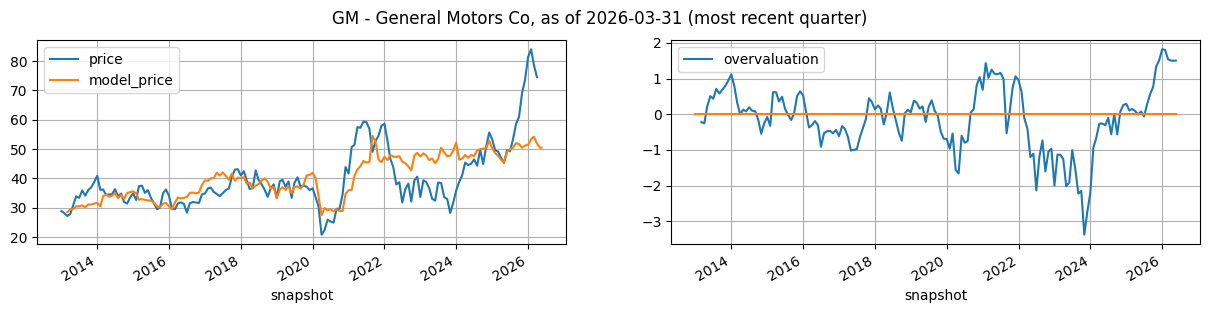

GM(0001467858) model_price = 0.453749 * (0.808703 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +29.715178


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,288.168,221.794,24.212,81.32,0.808703,1.505717,47.704651,0.453749,29.715178,51.361106,1.818866
2026-02-01,2025-12-31,281.284,220.165,26.867,84.00,0.808703,1.671639,52.222043,0.453749,29.715178,53.410867,1.798051
2026-03-01,2025-12-31,281.284,220.165,26.867,78.71,0.808703,1.735323,53.933041,0.453749,29.715178,54.187230,1.540508
2026-04-01,2025-12-31,281.284,220.165,26.867,74.50,0.808703,1.548398,48.910932,0.453749,29.715178,51.908454,1.499788
2026-05-01,2026-03-31,280.974,218.315,23.756,NaN,0.808703,1.548398,45.693167,0.453749,29.715178,50.448397,1.499788
2026-05-20,2026-03-31,280.974,218.315,23.756,NaN,0.808703,1.548398,45.693167,0.453749,29.715178,50.448397,1.499788


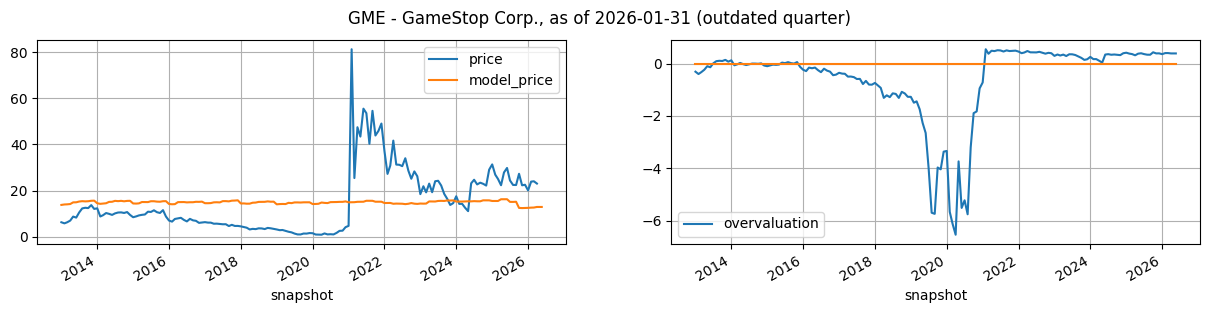

GME(0001326380) model_price = 1.033065 * (0.001411 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +17.008784


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-01,10.5507,5.2477,0.5835,20.08,0.001411,1.505717,-4.354225,1.033065,17.008784,12.510585,0.361757
2026-02-01,2025-11-01,10.5507,5.2477,0.5835,23.88,0.001411,1.671639,-4.257410,1.033065,17.008784,12.610601,0.402170
2026-03-01,2025-11-01,10.5507,5.2477,0.5835,24.03,0.001411,1.735323,-4.220250,1.033065,17.008784,12.648990,0.402893
2026-04-01,2026-01-31,10.3884,4.9440,0.6148,23.04,0.001411,1.548398,-3.977385,1.033065,17.008784,12.899885,0.388632
2026-05-01,2026-01-31,10.3884,4.9440,0.6148,NaN,0.001411,1.548398,-3.977385,1.033065,17.008784,12.899885,0.388632
2026-05-20,2026-01-31,10.3884,4.9440,0.6148,NaN,0.001411,1.548398,-3.977385,1.033065,17.008784,12.899885,0.388632


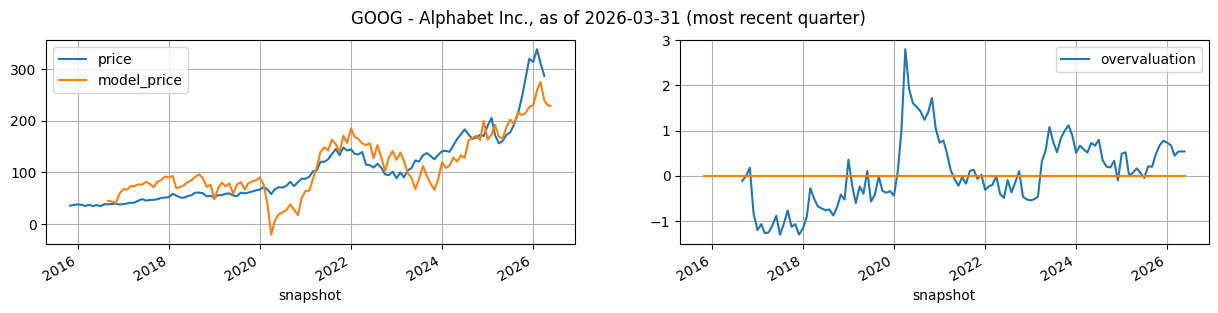

GOOG(0001652044) model_price = 1.158539 * (0.198204 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +15.714429


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,536.469,149.602,151.424,313.80,0.198204,1.505717,184.730032,1.158539,15.714429,229.731458,0.733581
2026-02-01,2025-09-30,536.469,149.602,151.424,338.53,0.198204,1.671639,209.854576,1.158539,15.714429,258.839233,0.671811
2026-03-01,2025-12-31,595.281,180.016,164.713,311.43,0.198204,1.735323,223.801342,1.158539,15.714429,274.997111,0.446762
2026-04-01,2025-12-31,595.281,180.016,164.713,286.86,0.198204,1.548398,193.012395,1.158539,15.714429,239.326901,0.539345
2026-05-01,2026-03-31,703.919,225.173,174.353,NaN,0.198204,1.548398,184.314440,1.158539,15.714429,229.249977,0.539345
2026-05-20,2026-03-31,703.919,225.173,174.353,NaN,0.198204,1.548398,184.314440,1.158539,15.714429,229.249977,0.539345


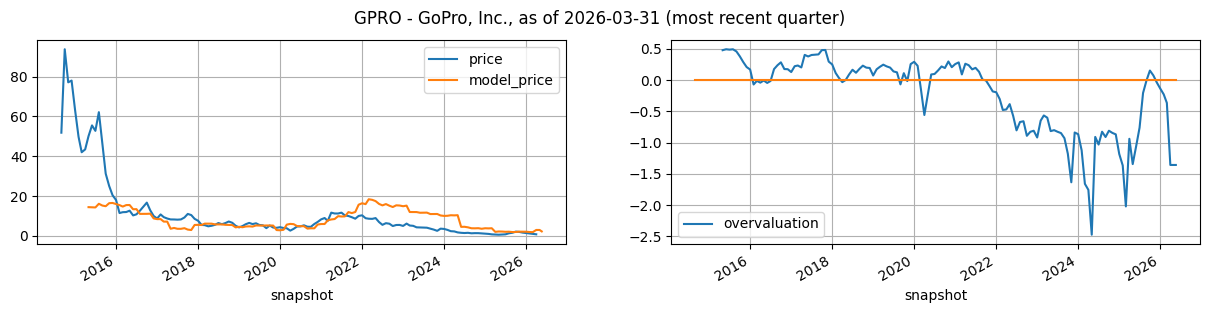

GPRO(0001500435) model_price = 15.629603 * (1.002570 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +2.241287


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,0.538608,0.458114,-0.061371,1.410,1.00257,1.505717,-0.010529,15.629603,2.241287,2.076721,-0.133499
2026-02-01,2025-09-30,0.538608,0.458114,-0.061371,1.160,1.00257,1.671639,-0.020712,15.629603,2.241287,1.917568,-0.226821
2026-03-01,2025-09-30,0.538608,0.458114,-0.061371,0.968,1.00257,1.735323,-0.024620,15.629603,2.241287,1.856482,-0.363926
2026-04-01,2025-12-31,0.427983,0.351433,-0.020669,0.770,1.00257,1.548398,0.045646,15.629603,2.241287,2.954717,-1.357836
2026-05-01,2025-12-31,0.427983,0.351433,-0.020669,NaN,1.00257,1.548398,0.045646,15.629603,2.241287,2.954717,-1.357836
2026-05-20,2026-03-31,0.381355,0.383224,-0.000101,NaN,1.00257,1.548398,-0.001045,15.629603,2.241287,2.224950,-1.357836


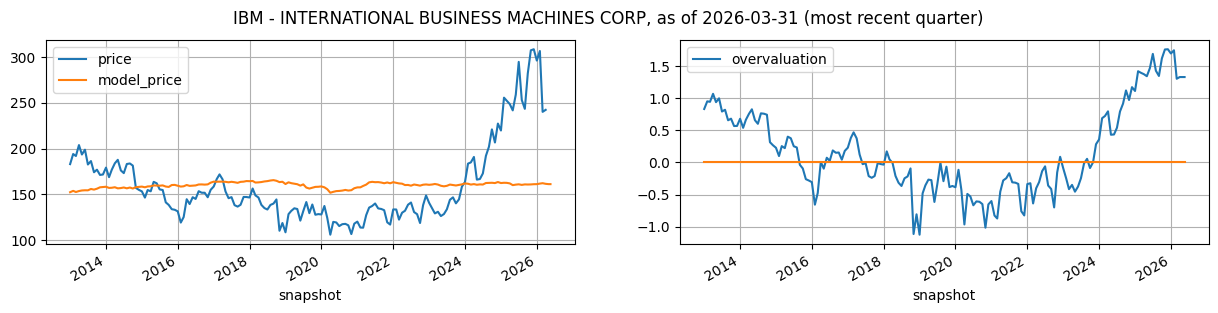

IBM(0000051143) model_price = 0.273887 * (0.357993 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +173.777475


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,146.312,118.407,13.483,296.21,0.357993,1.505717,-45.726676,0.273887,173.777475,161.253514,1.701261
2026-02-01,2025-09-30,146.312,118.407,13.483,306.70,0.357993,1.671639,-43.489552,0.273887,173.777475,161.866234,1.751232
2026-03-01,2025-12-31,151.880,119.232,13.193,240.21,0.357993,1.735323,-41.965837,0.273887,173.777475,162.283560,1.306825
2026-04-01,2025-12-31,151.880,119.232,13.193,242.39,0.357993,1.548398,-44.431936,0.273887,173.777475,161.608126,1.333469
2026-05-01,2026-03-31,156.229,123.255,13.992,NaN,0.357993,1.548398,-45.660852,0.273887,173.777475,161.271542,1.333469
2026-05-20,2026-03-31,156.229,123.255,13.992,NaN,0.357993,1.548398,-45.660852,0.273887,173.777475,161.271542,1.333469


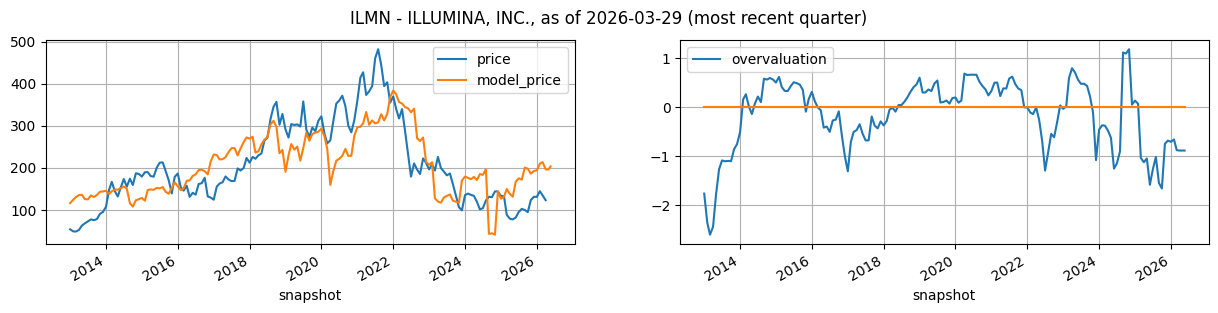

ILMN(0001110803) model_price = 85.344931 * (0.364384 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +181.948951


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-28,6.177,3.796,1.122,131.16,0.364384,1.505717,0.144216,85.344931,181.948951,194.257057,-0.709209
2026-02-01,2025-09-28,6.177,3.796,1.122,144.81,0.364384,1.671639,0.330380,85.344931,181.948951,210.145234,-0.661952
2026-03-01,2025-12-28,6.644,3.921,1.079,134.46,0.364384,1.735323,0.372382,85.344931,181.948951,213.729888,-0.880705
2026-04-01,2025-12-28,6.644,3.921,1.079,123.26,0.364384,1.548398,0.170690,85.344931,181.948951,196.516509,-0.888267
2026-05-01,2025-12-28,6.644,3.921,1.079,NaN,0.364384,1.548398,0.170690,85.344931,181.948951,196.516509,-0.888267
2026-05-20,2026-03-29,6.559,3.883,1.128,NaN,0.364384,1.548398,0.253589,85.344931,181.948951,203.591506,-0.888267


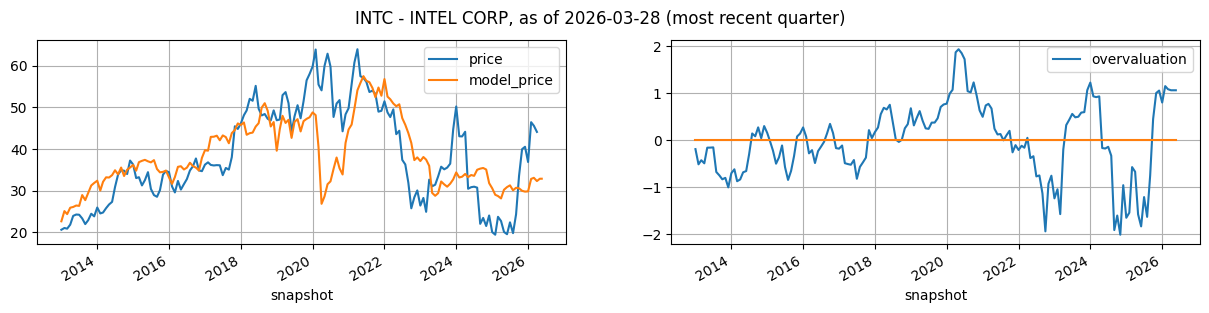

INTC(0000050863) model_price = 0.430508 * (0.384077 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.720340


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-27,204.514,98.138,8.574,36.90,0.384077,1.505717,-6.678945,0.430508,32.72034,29.844997,0.797718
2026-02-01,2025-12-27,211.429,97.148,9.697,46.47,0.384077,1.671639,0.266808,0.430508,32.72034,32.835203,1.147058
2026-03-01,2025-12-27,211.429,97.148,9.697,45.61,0.384077,1.735323,0.884352,0.430508,32.72034,33.101061,1.081604
2026-04-01,2025-12-27,211.429,97.148,9.697,44.13,0.384077,1.548398,-0.928258,0.430508,32.72034,32.320717,1.058855
2026-05-01,2026-03-28,205.332,93.938,9.980,NaN,0.384077,1.548398,0.378224,0.430508,32.72034,32.883168,1.058855
2026-05-20,2026-03-28,205.332,93.938,9.980,NaN,0.384077,1.548398,0.378224,0.430508,32.72034,32.883168,1.058855


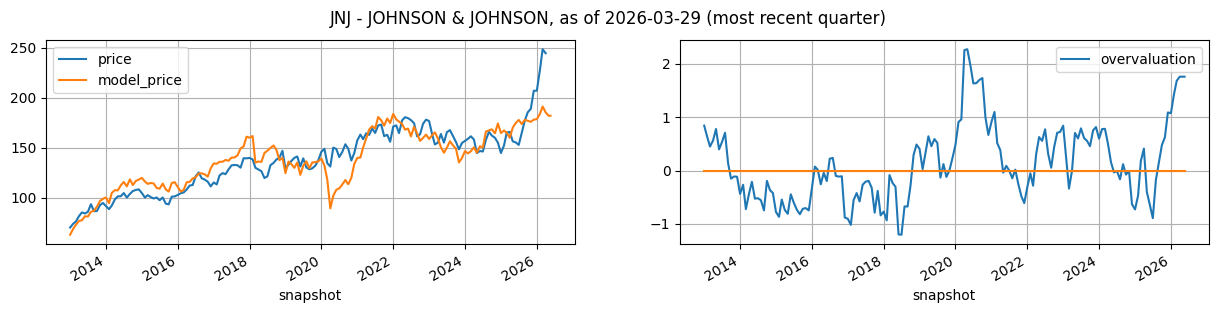

JNJ(0000200406) model_price = 1.295910 * (1.215638 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -25.326038


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-28,192.816,113.539,24.204,206.95,1.215638,1.505717,157.299777,1.29591,-25.326038,178.520321,1.074553
2026-02-01,2025-09-28,192.816,113.539,24.204,227.25,1.215638,1.671639,161.315748,1.29591,-25.326038,183.724658,1.428831
2026-03-01,2025-12-28,199.210,117.666,24.530,248.43,1.215638,1.735323,167.068658,1.29591,-25.326038,191.179912,1.683418
2026-04-01,2025-12-28,199.210,117.666,24.530,244.44,1.215638,1.548398,162.483392,1.29591,-25.326038,185.237820,1.760268
2026-05-01,2026-03-29,200.894,119.708,22.870,NaN,1.215638,1.548398,159.918185,1.29591,-25.326038,181.913542,1.760268
2026-05-20,2026-03-29,200.894,119.708,22.870,NaN,1.215638,1.548398,159.918185,1.29591,-25.326038,181.913542,1.760268


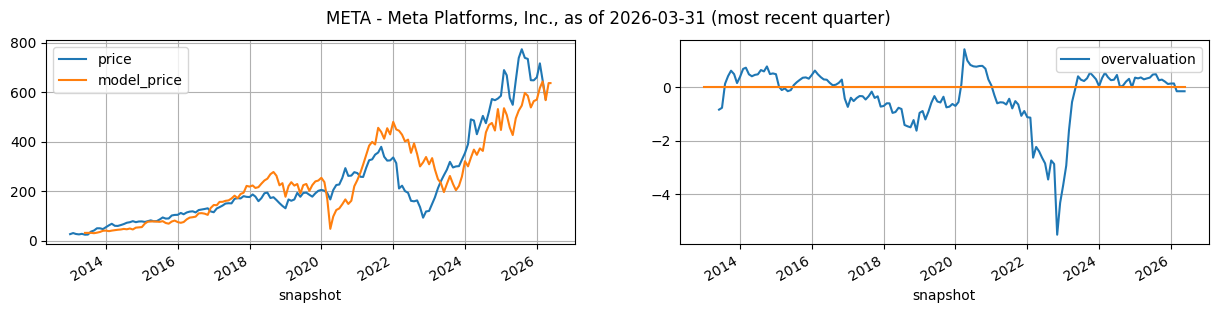

META(0001326801) model_price = 3.478719 * (0.338861 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +30.159710


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,303.844,109.778,107.574,660.09,0.338861,1.505717,155.158845,3.478719,30.15971,569.913709,0.129584
2026-02-01,2025-12-31,366.021,148.778,115.800,716.50,0.338861,1.671639,168.827968,3.478719,30.15971,617.464743,0.133158
2026-03-01,2025-12-31,366.021,148.778,115.800,648.18,0.338861,1.735323,176.202573,3.478719,30.15971,643.118922,-0.156590
2026-04-01,2025-12-31,366.021,148.778,115.800,572.13,0.338861,1.548398,154.556680,3.478719,30.15971,567.818944,-0.157197
2026-05-01,2026-03-31,395.250,151.569,124.000,NaN,0.338861,1.548398,174.367107,3.478719,30.15971,636.733852,-0.157197
2026-05-20,2026-03-31,395.250,151.569,124.000,NaN,0.338861,1.548398,174.367107,3.478719,30.15971,636.733852,-0.157197


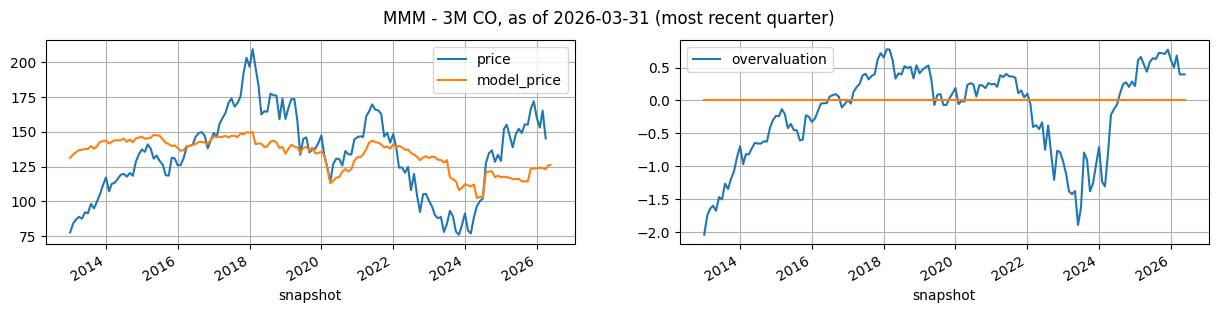

MMM(0000066740) model_price = 1.525688 * (0.003824 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +167.958174


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,37.611,32.983,2.541,160.10,0.003824,1.505717,-29.013131,1.525688,167.958174,123.693189,0.614997
2026-02-01,2025-09-30,37.611,32.983,2.541,153.16,0.003824,1.671639,-28.591524,1.525688,167.958174,124.336430,0.501836
2026-03-01,2025-12-31,37.733,33.031,2.306,165.32,0.003824,1.735323,-28.885037,1.525688,167.958174,123.888621,0.681993
2026-04-01,2025-12-31,37.733,33.031,2.306,145.23,0.003824,1.548398,-29.316086,1.525688,167.958174,123.230975,0.395868
2026-05-01,2026-03-31,35.436,32.173,2.959,NaN,0.003824,1.548398,-27.455767,1.525688,167.958174,126.069242,0.395868
2026-05-20,2026-03-31,35.436,32.173,2.959,NaN,0.003824,1.548398,-27.455767,1.525688,167.958174,126.069242,0.395868


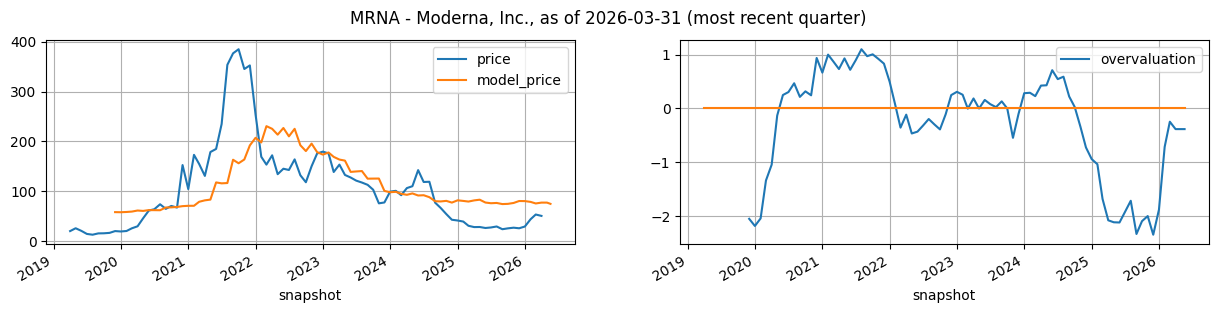

MRNA(0001682852) model_price = 4.858031 * (0.887168 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +56.264021


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,12.135,2.805,-1.978,29.49,0.887168,1.505717,4.982474,4.858031,56.264021,80.469032,-1.877750
2026-02-01,2025-09-30,12.135,2.805,-1.978,44.07,0.887168,1.671639,4.654281,4.858031,56.264021,78.874659,-0.712482
2026-03-01,2025-12-31,12.338,3.688,-1.873,53.57,0.887168,1.735323,4.007618,4.858031,56.264021,75.733151,-0.245799
2026-04-01,2025-12-31,12.338,3.688,-1.873,50.80,0.887168,1.548398,4.357728,4.858031,56.264021,77.433997,-0.383021
2026-05-01,2025-12-31,12.338,3.688,-1.873,NaN,0.887168,1.548398,4.357728,4.858031,56.264021,77.433997,-0.383021
2026-05-20,2026-03-31,11.488,4.080,-1.466,NaN,0.887168,1.548398,3.841833,4.858031,56.264021,74.927765,-0.383021


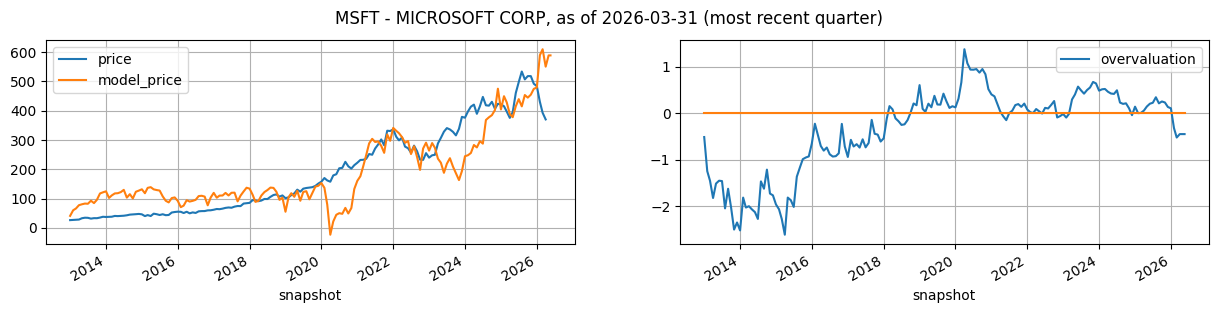

MSFT(0000789019) model_price = 1.979584 * (0.343105 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +149.518838


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,636.351,273.275,147.039,483.62,0.343105,1.505717,166.459100,1.979584,149.518838,479.038538,0.107259
2026-02-01,2025-12-31,665.302,274.427,160.506,430.29,0.343105,1.671639,222.149260,1.979584,149.518838,589.281865,-0.316509
2026-03-01,2025-12-31,665.302,274.427,160.506,392.74,0.343105,1.735323,232.370922,1.979584,149.518838,609.516499,-0.520536
2026-04-01,2025-12-31,665.302,274.427,160.506,370.17,0.343105,1.548398,202.368368,1.979584,149.518838,550.123935,-0.446935
2026-05-01,2026-03-31,694.228,279.861,170.141,NaN,0.343105,1.548398,221.777828,1.979584,149.518838,588.546584,-0.446935
2026-05-20,2026-03-31,694.228,279.861,170.141,NaN,0.343105,1.548398,221.777828,1.979584,149.518838,588.546584,-0.446935


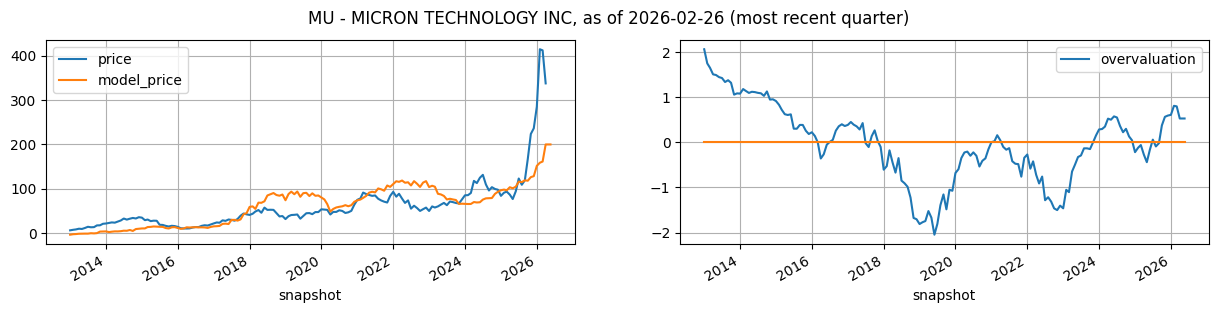

MU(0000723125) model_price = 1.862985 * (0.933174 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -10.656109


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-27,85.971,27.165,22.692,285.41,0.933174,1.505717,87.228645,1.862985,-10.656109,151.849522,0.608191
2026-02-01,2025-11-27,85.971,27.165,22.692,414.88,0.933174,1.671639,90.993742,1.862985,-10.656109,158.863842,0.807849
2026-03-01,2025-11-27,85.971,27.165,22.692,412.37,0.933174,1.735323,92.438859,1.862985,-10.656109,161.556073,0.795987
2026-04-01,2026-02-26,101.509,29.050,30.653,337.84,0.933174,1.548398,113.138619,1.862985,-10.656109,200.119408,0.527445
2026-05-01,2026-02-26,101.509,29.050,30.653,NaN,0.933174,1.548398,113.138619,1.862985,-10.656109,200.119408,0.527445
2026-05-20,2026-02-26,101.509,29.050,30.653,NaN,0.933174,1.548398,113.138619,1.862985,-10.656109,200.119408,0.527445


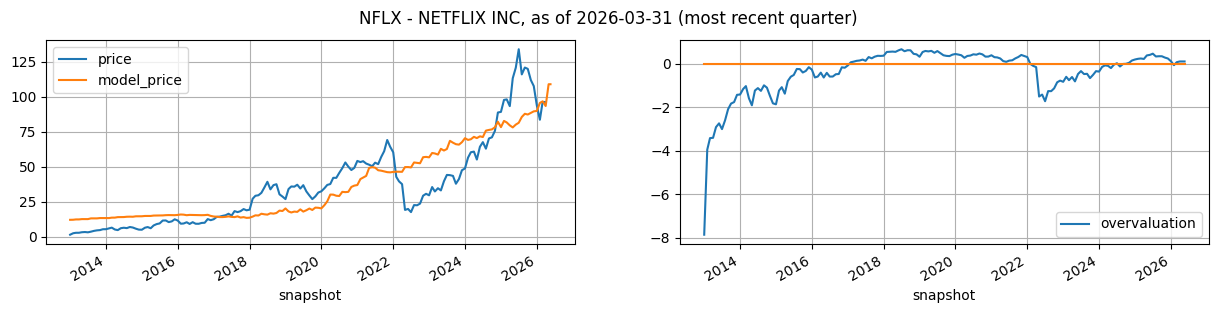

NFLX(0001065280) model_price = 1.757160 * (1.087974 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +10.354129


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,54.934835,28.980800,9.574525,93.76,1.087974,1.505717,45.203423,1.75716,10.354129,89.783773,0.123577
2026-02-01,2025-12-31,55.596993,28.981505,10.149273,83.49,1.087974,1.671639,48.472523,1.75716,10.354129,95.528104,-0.060316
2026-03-01,2025-12-31,55.596993,28.981505,10.149273,96.24,1.087974,1.735323,49.118869,1.75716,10.354129,96.663838,0.077442
2026-04-01,2025-12-31,55.596993,28.981505,10.149273,96.15,1.087974,1.548398,47.221718,1.75716,10.354129,93.330240,0.110684
2026-05-01,2026-03-31,61.015914,29.889515,12.650279,NaN,1.087974,1.548398,56.081909,1.75716,10.354129,108.899012,0.110684
2026-05-20,2026-03-31,61.015914,29.889515,12.650279,NaN,1.087974,1.548398,56.081909,1.75716,10.354129,108.899012,0.110684


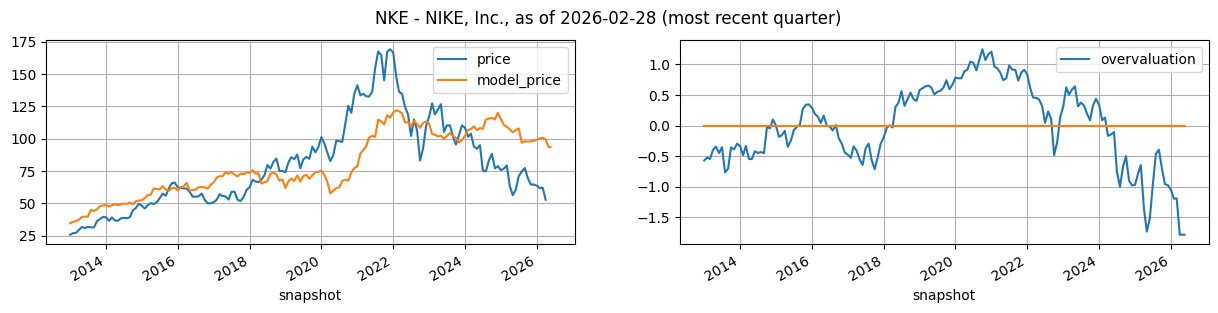

NKE(0000320187) model_price = 2.196503 * (1.769413 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -5.728806


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-30,37.787,23.702,3.056,63.71,1.769413,1.505717,47.760281,2.196503,-5.728806,99.176816,-1.051943
2026-02-01,2025-11-30,37.787,23.702,3.056,61.81,1.769413,1.671639,48.267338,2.196503,-5.728806,100.290568,-1.200781
2026-03-01,2025-11-30,37.787,23.702,3.056,62.18,1.769413,1.735323,48.461956,2.196503,-5.728806,100.718048,-1.194499
2026-04-01,2025-11-30,37.787,23.702,3.056,52.82,1.769413,1.548398,47.890714,2.196503,-5.728806,99.463312,-1.789395
2026-05-01,2026-02-28,37.064,22.974,1.694,NaN,1.769413,1.548398,45.230510,2.196503,-5.728806,93.620165,-1.789395
2026-05-20,2026-02-28,37.064,22.974,1.694,NaN,1.769413,1.548398,45.230510,2.196503,-5.728806,93.620165,-1.789395


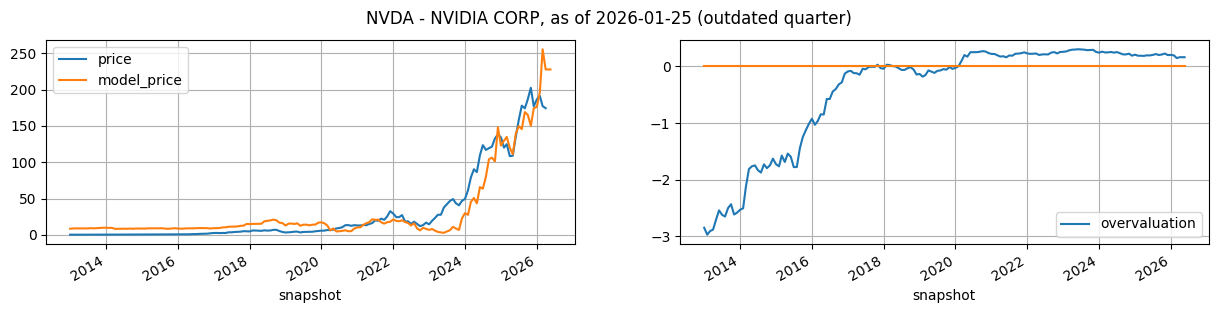

NVDA(0001045810) model_price = 1.447799 * (0.196214 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +10.358880


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-26,161.148,42.251,83.159,186.50,0.196214,1.505717,114.582414,1.447799,10.35888,176.251207,0.202996
2026-02-01,2025-10-26,161.148,42.251,83.159,191.13,0.196214,1.671639,128.380305,1.447799,10.35888,196.227784,0.193655
2026-03-01,2026-01-25,206.803,49.510,102.718,177.19,0.196214,1.735323,169.316529,1.447799,10.35888,255.495217,0.146137
2026-04-01,2026-01-25,206.803,49.510,102.718,174.40,0.196214,1.548398,150.115986,1.447799,10.35888,227.696685,0.161737
2026-05-01,2026-01-25,206.803,49.510,102.718,NaN,0.196214,1.548398,150.115986,1.447799,10.35888,227.696685,0.161737
2026-05-20,2026-01-25,206.803,49.510,102.718,NaN,0.196214,1.548398,150.115986,1.447799,10.35888,227.696685,0.161737


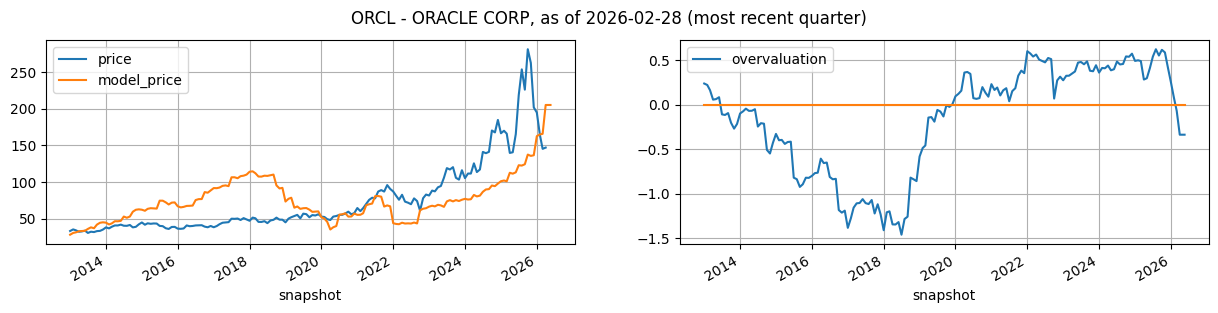

ORCL(0001341439) model_price = 0.608401 * (2.451226 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -56.873382


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-30,204.984,175.033,22.296,194.91,2.451226,1.505717,361.000484,0.608401,-56.873382,162.759518,0.253009
2026-02-01,2025-11-30,204.984,175.033,22.296,164.58,2.451226,1.671639,364.699877,0.608401,-56.873382,165.010231,0.076642
2026-03-01,2025-11-30,204.984,175.033,22.296,145.40,2.451226,1.735323,366.119775,0.608401,-56.873382,165.874098,-0.068817
2026-04-01,2026-02-28,245.240,206.745,23.514,147.11,2.451226,1.548398,430.802583,0.608401,-56.873382,205.227155,-0.336421
2026-05-01,2026-02-28,245.240,206.745,23.514,NaN,2.451226,1.548398,430.802583,0.608401,-56.873382,205.227155,-0.336421
2026-05-20,2026-02-28,245.240,206.745,23.514,NaN,2.451226,1.548398,430.802583,0.608401,-56.873382,205.227155,-0.336421


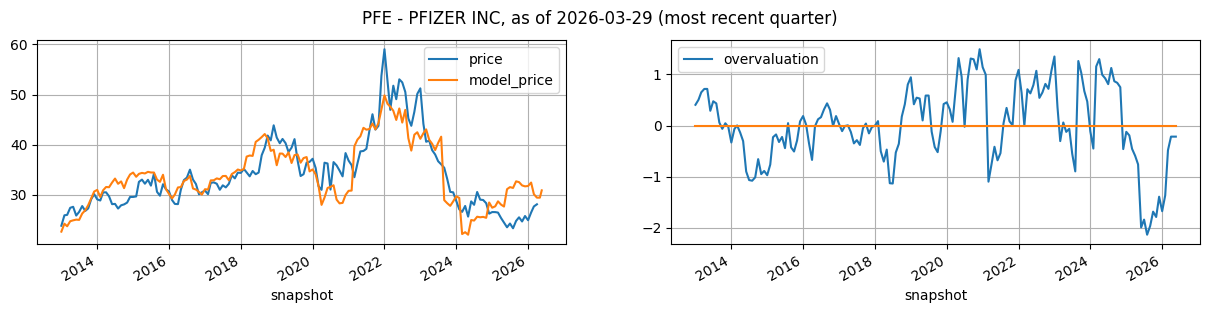

PFE(0000078003) model_price = 0.316920 * (0.024250 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +60.630883


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-28,208.731,115.930,13.077,24.90,0.02425,1.505717,-91.178053,0.31692,60.630883,31.734720,-1.675250
2026-02-01,2025-09-28,208.731,115.930,13.077,26.44,0.02425,1.671639,-89.008293,0.31692,60.630883,32.422361,-1.365701
2026-03-01,2025-12-31,208.160,121.684,11.704,27.65,0.02425,1.735323,-96.325943,0.31692,60.630883,30.103250,-0.482876
2026-04-01,2025-12-31,208.160,121.684,11.704,28.08,0.02425,1.548398,-98.513711,0.31692,60.630883,29.409902,-0.217368
2026-05-01,2025-12-31,208.160,121.684,11.704,NaN,0.02425,1.548398,-98.513711,0.31692,60.630883,29.409902,-0.217368
2026-05-20,2026-03-29,207.618,117.517,11.984,NaN,0.02425,1.548398,-93.926303,0.31692,60.630883,30.863745,-0.217368


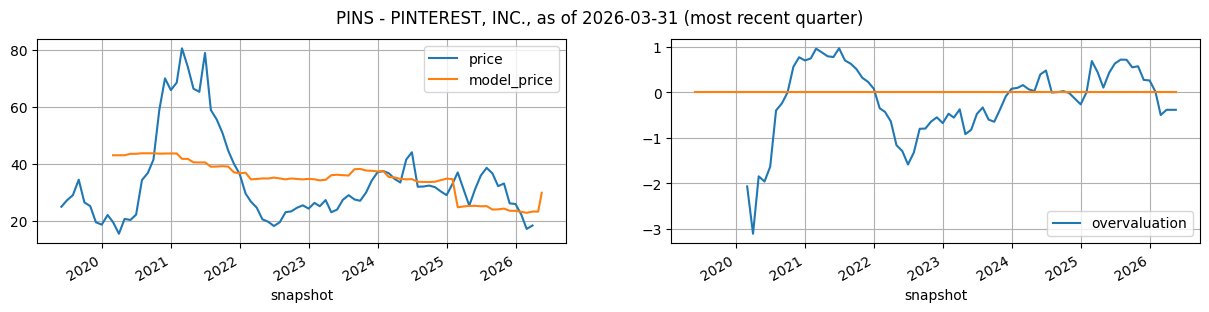

PINS(0001506293) model_price = -1.819958 * (2.986540 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +55.347755


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,5.515410,0.690442,1.147046,25.89,2.98654,1.505717,17.508678,-1.819958,55.347755,23.482705,0.263512
2026-02-01,2025-09-30,5.515410,0.690442,1.147046,22.13,2.98654,1.671639,17.698998,-1.819958,55.347755,23.136331,0.015299
2026-03-01,2025-12-31,5.492132,0.746894,1.284264,17.13,2.98654,1.735323,17.884191,-1.819958,55.347755,22.799287,-0.496496
2026-04-01,2025-12-31,5.492132,0.746894,1.284264,18.34,2.98654,1.548398,17.644130,-1.819958,55.347755,23.236187,-0.381781
2026-05-01,2025-12-31,5.492132,0.746894,1.284264,NaN,2.98654,1.548398,17.644130,-1.819958,55.347755,23.236187,-0.381781
2026-05-20,2026-03-31,4.645279,1.794695,1.248581,NaN,2.98654,1.548398,14.011918,-1.819958,55.347755,29.846660,-0.381781


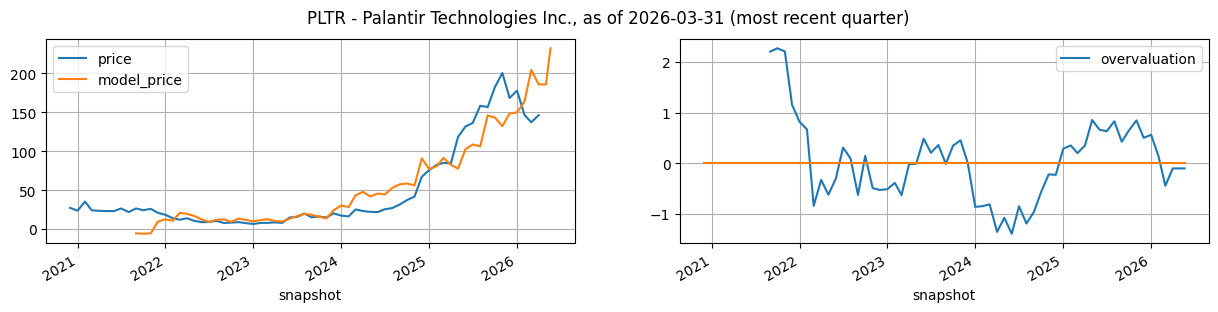

PLTR(0001321655) model_price = 46.673317 * (0.246078 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -0.049118


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,8.113960,1.523503,1.817505,177.75,0.246078,1.505717,3.209814,46.673317,-0.049118,149.763533,0.561664
2026-02-01,2025-09-30,8.113960,1.523503,1.817505,146.59,0.246078,1.671639,3.511377,46.673317,-0.049118,163.838511,0.134555
2026-03-01,2025-12-31,8.900392,1.513124,2.134473,137.19,0.246078,1.735323,4.381068,46.673317,-0.049118,204.429854,-0.443680
2026-04-01,2025-12-31,8.900392,1.513124,2.134473,146.28,0.246078,1.548398,3.982082,46.673317,-0.049118,185.807855,-0.102286
2026-05-01,2025-12-31,8.900392,1.513124,2.134473,NaN,0.246078,1.548398,3.982082,46.673317,-0.049118,185.807855,-0.102286
2026-05-20,2026-03-31,10.199183,1.749520,2.723375,NaN,0.246078,1.548398,4.977145,46.673317,-0.049118,232.250740,-0.102286


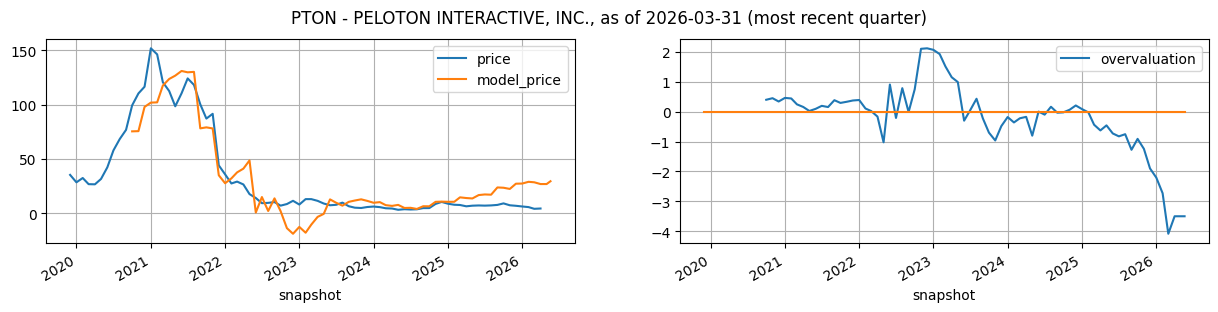

PTON(0001639825) model_price = 24.341973 * (1.441969 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.014513


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,2.1701,2.5171,0.3924,6.16,1.441969,1.505717,1.202960,24.341973,-2.014513,27.267900,-2.205863
2026-02-01,2025-09-30,2.1701,2.5171,0.3924,5.59,1.441969,1.671639,1.268067,24.341973,-2.014513,28.852750,-2.726931
2026-03-01,2025-12-31,2.1646,2.4913,0.3576,4.02,1.441969,1.735323,1.250537,24.341973,-2.014513,28.426024,-4.080964
2026-04-01,2025-12-31,2.1646,2.4913,0.3576,4.29,1.441969,1.548398,1.183693,24.341973,-2.014513,26.798901,-3.496484
2026-05-01,2025-12-31,2.1646,2.4913,0.3576,NaN,1.441969,1.548398,1.183693,24.341973,-2.014513,26.798901,-3.496484
2026-05-20,2026-03-31,2.0174,2.2593,0.4136,NaN,1.441969,1.548398,1.290145,24.341973,-2.014513,29.390165,-3.496484


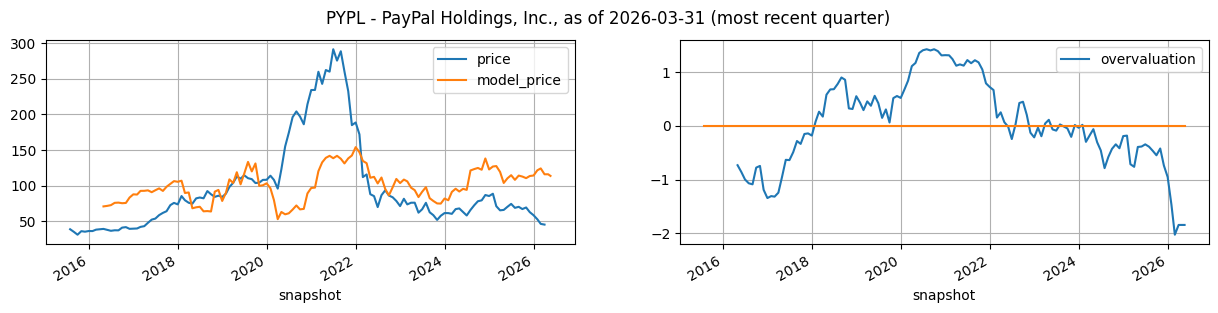

PYPL(0001633917) model_price = 6.856569 * (0.827438 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +3.757307


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,79.801,59.603,6.426,58.38,0.827438,1.505717,16.103138,6.856569,3.757307,114.169576,-0.953247
2026-02-01,2025-09-30,79.801,59.603,6.426,52.69,0.827438,1.671639,17.169351,6.856569,3.757307,121.480142,-1.467223
2026-03-01,2025-12-31,80.173,59.917,6.416,46.21,0.827438,1.735323,17.555038,6.856569,3.757307,124.124632,-2.026142
2026-04-01,2025-12-31,80.173,59.917,6.416,45.23,0.827438,1.548398,16.355729,6.856569,3.757307,115.901484,-1.844591
2026-05-01,2025-12-31,80.173,59.917,6.416,NaN,0.827438,1.548398,16.355729,6.856569,3.757307,115.901484,-1.844591
2026-05-20,2026-03-31,80.546,60.522,6.390,NaN,0.827438,1.548398,16.019105,6.856569,3.757307,113.593399,-1.844591


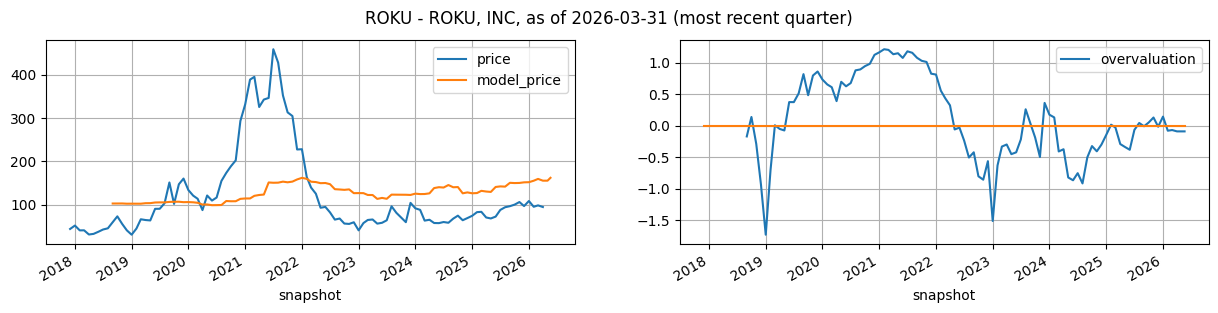

ROKU(0001428439) model_price = 45.064499 * (0.498563 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +102.157216


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,4.397285,1.772199,0.455360,108.49,0.498563,1.505717,1.105767,45.064499,102.157216,151.988073,0.144992
2026-02-01,2025-09-30,4.397285,1.772199,0.455360,95.20,0.498563,1.671639,1.181322,45.064499,102.157216,155.392883,-0.078396
2026-03-01,2025-12-31,4.433483,1.775538,0.483718,98.41,0.498563,1.735323,1.274239,45.064499,102.157216,159.580160,-0.068070
2026-04-01,2025-12-31,4.433483,1.775538,0.483718,94.62,0.498563,1.548398,1.183820,45.064499,102.157216,155.505477,-0.089207
2026-05-01,2025-12-31,4.433483,1.775538,0.483718,NaN,0.498563,1.548398,1.183820,45.064499,102.157216,155.505477,-0.089207
2026-05-20,2026-03-31,4.352634,1.681570,0.544126,NaN,0.498563,1.548398,1.331015,45.064499,102.157216,162.138761,-0.089207


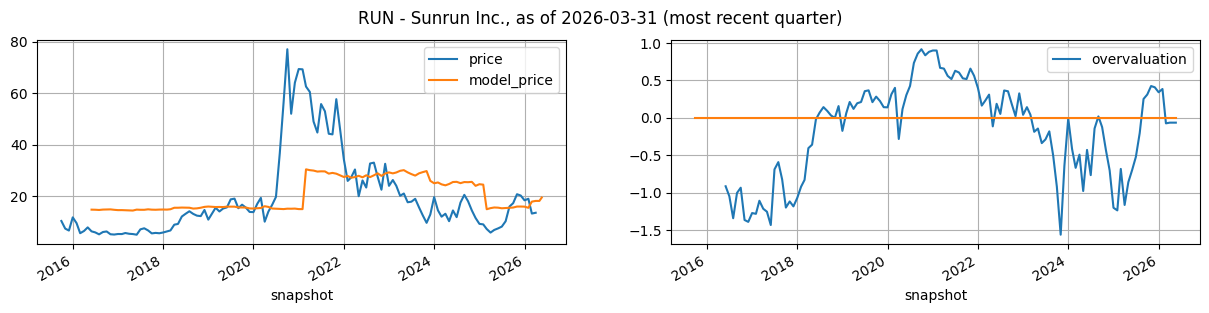

RUN(0001469367) model_price = 3.446151 * (0.948123 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.656588


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,22.225482,19.241580,-0.776747,18.40,0.948123,1.505717,0.661341,3.446151,13.656588,15.935668,0.342714
2026-02-01,2025-09-30,22.225482,19.241580,-0.776747,19.00,0.948123,1.671639,0.532462,3.446151,13.656588,15.491531,0.386257
2026-03-01,2025-12-31,22.610596,19.478112,-0.421440,13.25,0.948123,1.735323,1.228171,3.446151,13.656588,17.889050,-0.072796
2026-04-01,2025-12-31,22.610596,19.478112,-0.421440,13.56,0.948123,1.548398,1.306949,3.446151,13.656588,18.160529,-0.063487
2026-05-01,2025-12-31,22.610596,19.478112,-0.421440,NaN,0.948123,1.548398,1.306949,3.446151,13.656588,18.160529,-0.063487
2026-05-20,2026-03-31,22.765093,19.424339,-0.306611,NaN,0.948123,1.548398,1.685005,3.446151,13.656588,19.463368,-0.063487


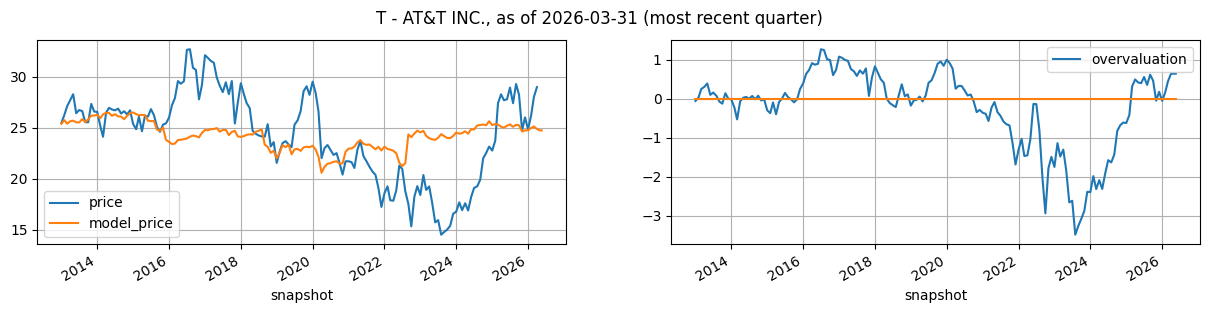

T(0000732717) model_price = 0.033462 * (0.003567 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.572154


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,423.213,296.458,40.860,24.84,0.003567,1.505717,-233.424686,0.033462,32.572154,24.761350,-0.055887
2026-02-01,2025-09-30,423.213,296.458,40.860,26.21,0.003567,1.671639,-226.645121,0.033462,32.572154,24.988207,0.162738
2026-03-01,2025-12-31,420.198,293.707,40.284,28.01,0.003567,1.735323,-222.302295,0.033462,32.572154,25.133525,0.444912
2026-04-01,2025-12-31,420.198,293.707,40.284,28.99,0.003567,1.548398,-229.832374,0.033462,32.572154,24.881555,0.641274
2026-05-01,2026-03-31,421.188,295.569,38.792,NaN,0.003567,1.548398,-234.001053,0.033462,32.572154,24.742064,0.641274
2026-05-20,2026-03-31,421.188,295.569,38.792,NaN,0.003567,1.548398,-234.001053,0.033462,32.572154,24.742064,0.641274


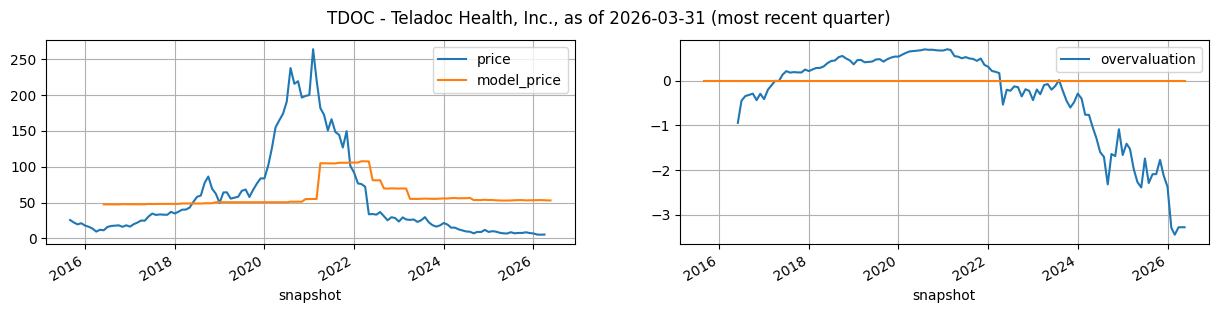

TDOC(0001477449) model_price = 4.509077 * (0.832668 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.122501


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,2.878547,1.486432,0.292517,7.00,0.832668,1.505717,1.350889,4.509077,47.122501,53.213766,-2.375625
2026-02-01,2025-09-30,2.878547,1.486432,0.292517,5.45,0.832668,1.671639,1.399424,4.509077,47.122501,53.432613,-3.294034
2026-03-01,2025-12-31,2.858300,1.472594,0.294357,5.26,0.832668,1.735323,1.418225,4.509077,47.122501,53.517387,-3.448449
2026-04-01,2025-12-31,2.858300,1.472594,0.294357,5.45,0.832668,1.548398,1.363202,4.509077,47.122501,53.269286,-3.281536
2026-05-01,2026-03-31,2.807261,1.470945,0.287954,NaN,0.832668,1.548398,1.312438,4.509077,47.122501,53.040387,-3.281536
2026-05-20,2026-03-31,2.807261,1.470945,0.287954,NaN,0.832668,1.548398,1.312438,4.509077,47.122501,53.040387,-3.281536


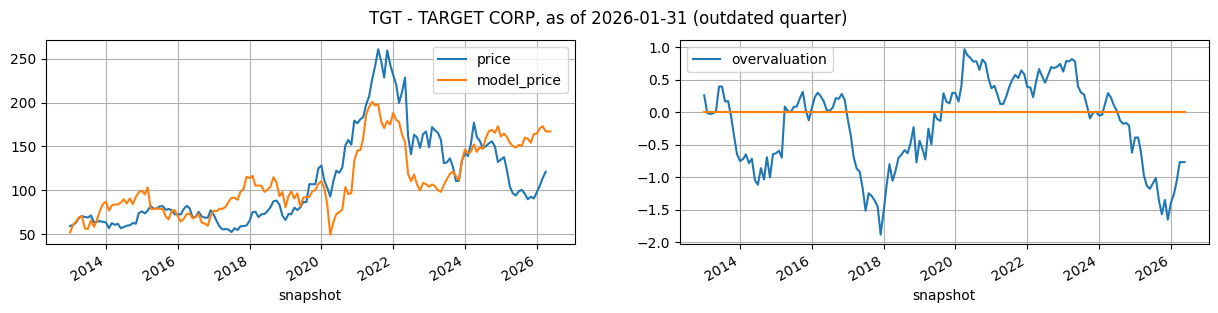

TGT(0000027419) model_price = 5.359136 * (1.358928 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -88.305869


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-11-01,59.991,44.490,6.774,97.75,1.358928,1.505717,47.233155,5.359136,-88.305869,164.823008,-1.395177
2026-02-01,2025-11-01,59.991,44.490,6.774,105.47,1.358928,1.671639,48.357109,5.359136,-88.305869,170.846432,-1.259348
2026-03-01,2025-11-01,59.991,44.490,6.774,113.79,1.358928,1.735323,48.788505,5.359136,-88.305869,173.158338,-1.058359
2026-04-01,2026-01-31,59.490,43.325,6.562,121.20,1.358928,1.548398,47.678193,5.359136,-88.305869,167.208026,-0.767221
2026-05-01,2026-01-31,59.490,43.325,6.562,NaN,1.358928,1.548398,47.678193,5.359136,-88.305869,167.208026,-0.767221
2026-05-20,2026-01-31,59.490,43.325,6.562,NaN,1.358928,1.548398,47.678193,5.359136,-88.305869,167.208026,-0.767221


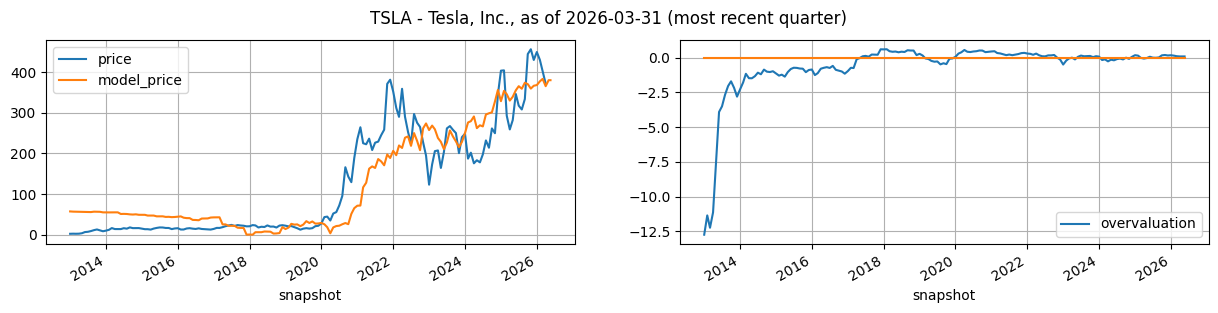

TSLA(0001318605) model_price = 6.520278 * (0.581432 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +57.293981


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,133.735,53.765,15.748,449.72,0.581432,1.505717,47.704826,6.520278,57.293981,368.342711,0.178686
2026-02-01,2025-12-31,137.806,55.669,14.747,430.41,0.581432,1.671639,49.107461,6.520278,57.293981,377.488281,0.148155
2026-03-01,2025-12-31,137.806,55.669,14.747,402.51,0.581432,1.735323,50.046609,6.520278,57.293981,383.611786,0.108142
2026-04-01,2025-12-31,137.806,55.669,14.747,371.75,0.581432,1.548398,47.290029,6.520278,57.293981,365.638116,0.092080
2026-05-01,2026-03-31,143.724,59.608,16.528,NaN,0.581432,1.548398,49.549640,6.520278,57.293981,380.371409,0.092080
2026-05-20,2026-03-31,143.724,59.608,16.528,NaN,0.581432,1.548398,49.549640,6.520278,57.293981,380.371409,0.092080


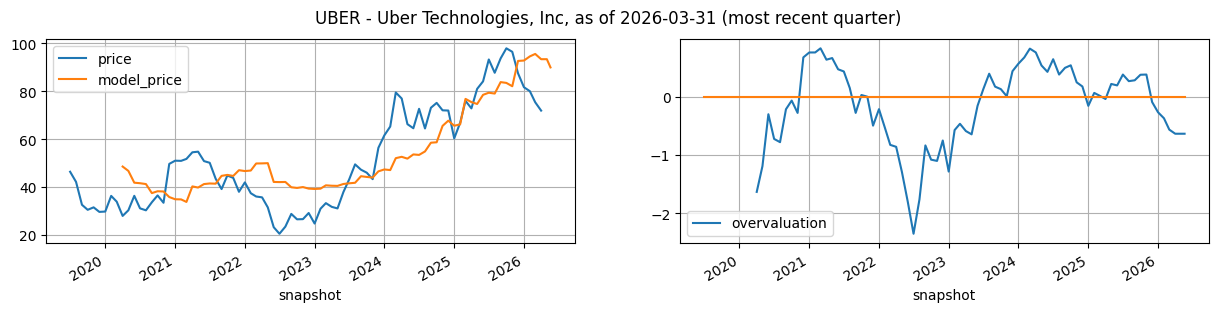

UBER(0001543151) model_price = 1.165202 * (1.364154 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +17.467812


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,63.344,35.210,8.966,81.71,1.364155,1.505717,64.701276,1.165202,17.467812,92.857865,-0.267361
2026-02-01,2025-09-30,63.344,35.210,8.966,80.05,1.364155,1.671639,66.188931,1.165202,17.467812,94.591284,-0.369914
2026-03-01,2025-12-31,61.802,34.761,10.099,75.42,1.364155,1.735323,67.071516,1.165202,17.467812,95.619673,-0.565348
2026-04-01,2025-12-31,61.802,34.761,10.099,71.93,1.364155,1.548398,65.183763,1.165202,17.467812,93.420059,-0.635503
2026-05-01,2025-12-31,61.802,34.761,10.099,NaN,1.364155,1.548398,65.183763,1.165202,17.467812,93.420059,-0.635503
2026-05-20,2026-03-31,59.885,35.134,10.126,NaN,1.364155,1.548398,62.237485,1.165202,17.467812,89.987050,-0.635503


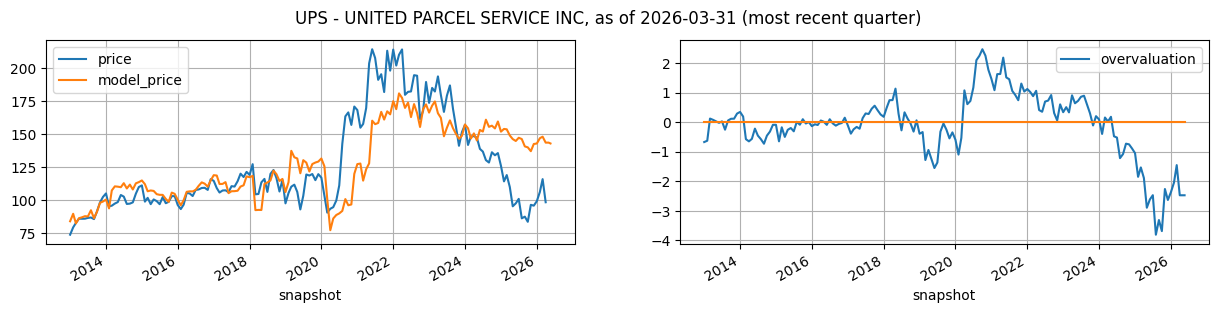

UPS(0001090727) model_price = 2.856344 * (0.699095 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +122.773062


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,71.392,55.569,8.463,99.19,0.699095,1.505717,7.083693,2.856344,122.773062,143.006527,-2.363611
2026-02-01,2025-09-30,71.392,55.569,8.463,106.22,0.699095,1.671639,8.487890,2.856344,122.773062,147.017395,-2.040834
2026-03-01,2025-12-31,73.090,56.863,8.450,115.96,0.699095,1.735323,8.897352,2.856344,122.773062,148.186960,-1.446498
2026-04-01,2025-12-31,73.090,56.863,8.450,98.38,0.699095,1.548398,7.317837,2.856344,122.773062,143.675322,-2.468117
2026-05-01,2025-12-31,73.090,56.863,8.450,NaN,0.699095,1.548398,7.317837,2.856344,122.773062,143.675322,-2.468117
2026-05-20,2026-03-31,71.809,56.046,8.356,NaN,0.699095,1.548398,7.093747,2.856344,122.773062,143.035243,-2.468117


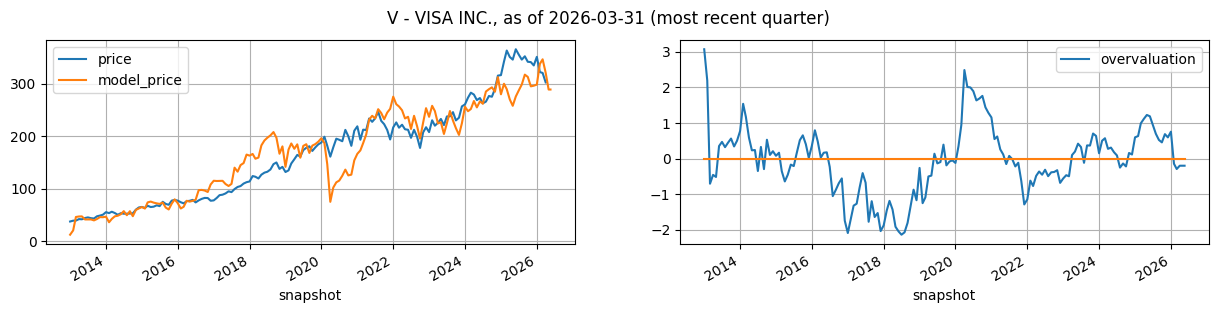

V(0001403161) model_price = 5.589192 * (0.985388 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -99.821549


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,99.627,61.718,23.059,350.71,0.985388,1.505717,71.173619,5.589192,-99.821549,297.981448,0.754926
2026-02-01,2025-12-31,96.814,58.037,24.443,321.83,0.985388,1.671639,78.222261,5.589192,-99.821549,337.377659,-0.146883
2026-03-01,2025-12-31,96.814,58.037,24.443,320.14,0.985388,1.735323,79.778888,5.589192,-99.821549,346.077950,-0.295372
2026-04-01,2025-12-31,96.814,58.037,24.443,302.24,0.985388,1.548398,75.209885,5.589192,-99.821549,320.540915,-0.202450
2026-05-01,2026-03-31,95.049,59.388,22.756,NaN,0.985388,1.548398,69.507527,5.589192,-99.821549,288.669342,-0.202450
2026-05-20,2026-03-31,95.049,59.388,22.756,NaN,0.985388,1.548398,69.507527,5.589192,-99.821549,288.669342,-0.202450


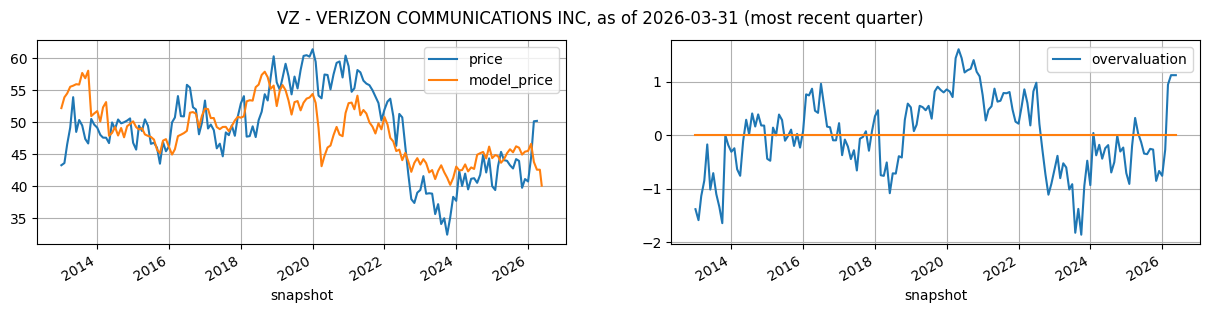

VZ(0000732712) model_price = 0.175249 * (0.012642 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +83.912960


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-09-30,388.331,281.986,38.455,40.73,0.012642,1.505717,-219.174254,0.175249,83.91296,45.502789,-0.758265
2026-02-01,2025-09-30,388.331,281.986,38.455,44.52,0.012642,1.671639,-212.793730,0.175249,83.91296,46.620972,-0.268645
2026-03-01,2025-12-31,404.258,298.517,37.137,50.14,0.012642,1.735323,-228.961565,0.175249,83.91296,43.787568,0.947793
2026-04-01,2025-12-31,404.258,298.517,37.137,50.20,0.012642,1.548398,-235.903392,0.175249,83.91296,42.571016,1.124627
2026-05-01,2025-12-31,404.258,298.517,37.137,NaN,0.012642,1.548398,-235.903392,0.175249,83.91296,42.571016,1.124627
2026-05-20,2026-03-31,417.882,313.260,37.339,NaN,0.012642,1.548398,-250.161377,0.175249,83.91296,40.072312,1.124627


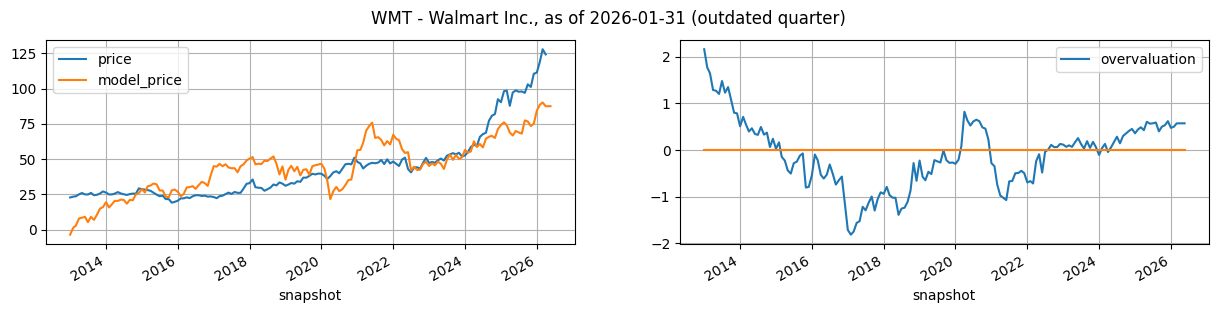

WMT(0000104169) model_price = 0.612951 * (1.269262 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -59.972378


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-31,288.655,192.561,40.977,111.41,1.269262,1.505717,235.517690,0.612951,-59.972378,84.388475,0.473391
2026-02-01,2025-10-31,288.655,192.561,40.977,119.14,1.269262,1.671639,242.316668,0.612951,-59.972378,88.555916,0.499313
2026-03-01,2025-10-31,288.655,192.561,40.977,127.95,1.269262,1.735323,244.926247,0.612951,-59.972378,90.155461,0.570089
2026-04-01,2026-01-31,284.668,185.051,41.565,124.28,1.269262,1.548398,240.626538,0.612951,-59.972378,87.519949,0.570819
2026-05-01,2026-01-31,284.668,185.051,41.565,NaN,1.269262,1.548398,240.626538,0.612951,-59.972378,87.519949,0.570819
2026-05-20,2026-01-31,284.668,185.051,41.565,NaN,1.269262,1.548398,240.626538,0.612951,-59.972378,87.519949,0.570819


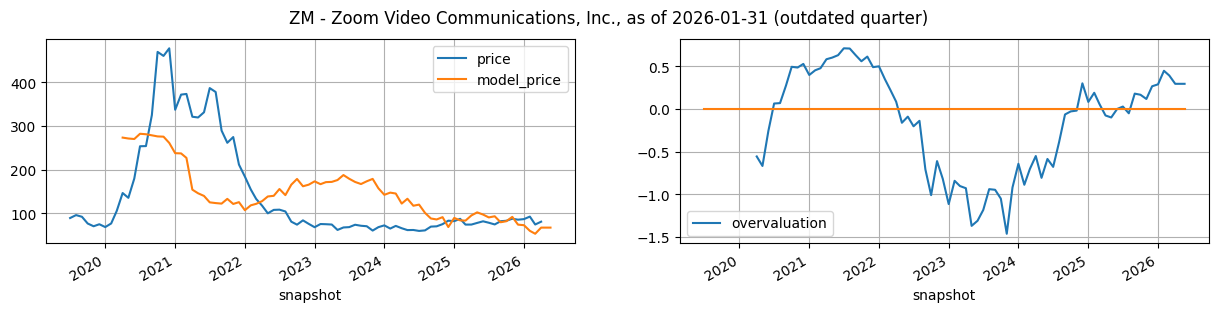

ZM(0001585521) model_price = -38.003621 * (0.376802 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +273.317375


,date,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,,,,,,,,,,,,
2026-01-01,2025-10-31,11.390811,2.103971,2.059093,86.29,0.376802,1.505717,5.288522,-38.003621,273.317375,72.334377,0.289054
2026-02-01,2025-10-31,11.390811,2.103971,2.059093,92.10,0.376802,1.671639,5.630171,-38.003621,273.317375,59.350499,0.448013
2026-03-01,2026-01-31,11.960416,2.152158,1.989048,73.94,0.376802,1.735323,5.806193,-38.003621,273.317375,52.661030,0.392419
2026-04-01,2026-01-31,11.960416,2.152158,1.989048,80.39,0.376802,1.548398,5.434390,-38.003621,273.317375,66.790869,0.295150
2026-05-01,2026-01-31,11.960416,2.152158,1.989048,NaN,0.376802,1.548398,5.434390,-38.003621,273.317375,66.790869,0.295150
2026-05-20,2026-01-31,11.960416,2.152158,1.989048,NaN,0.376802,1.548398,5.434390,-38.003621,273.317375,66.790869,0.295150


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    quarters_since_last_report = (datetime.today() - df['date'].max()) / timedelta(days=7) / 13
    caption = f"{ticker} - {name}"
    caption += f", as of {df['date'].max():%Y-%m-%d} ({"most recent" if quarters_since_last_report < 1 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    df[['price','model_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{}({}) model_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, cik, df['hype'].mean(), df['asmul'].mean(),
        "+" if df['bias'].mean() >= 0 else "", df['bias'].mean()
    ))

    # Display a few most recent records from the result set
    display(df.drop(columns=['cik','ticker']).tail(6))

for i in result[result.index.isin(sample_tickers, level='ticker')].groupby(by=['ticker','cik']):
    plot_ticker(i)

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together, as shown below. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

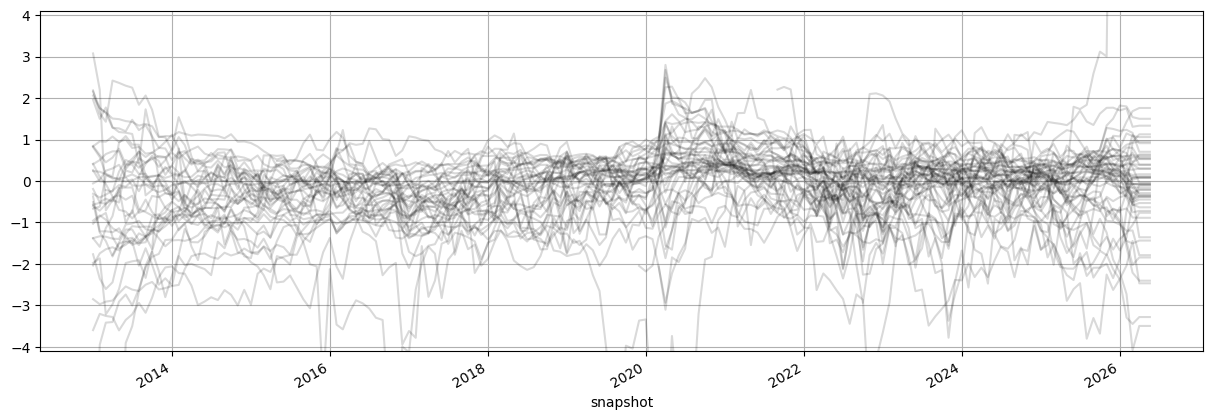

In [18]:
pd.pivot_table(result[result.index.isin(sample_tickers, level='ticker')],
               index='snapshot', columns='ticker', values='overvaluation').plot(
               grid=True, legend=False, c='black', alpha=0.15, figsize=(15,5),ylim=(-4.1,4.1))
plt.show()

In [19]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.